# ExpCLR: qué aprendió el espacio latente

Este cuaderno recorre los once codificadores de ExpCLR entrenados sobre el EEG longitudinal
de CIMCYC, que resultan de combinar tres descriptores expertos sobre el montaje completo con
dos sobre cada una de las cuatro regiones del cuero cabelludo, cada uno con diez pliegues por
sujeto. La pregunta que lo vertebra es topográfica, y consiste en determinar qué región ordena
mejor la maduración y con qué descriptor, a la que se suman otras tres sobre qué añade la
representación aprendida por encima de la señal cruda, sobre si el espacio codifica madurez o
identidad del niño, y sobre su utilidad para predecir la edad y el cociente intelectual.

La proyección a dos dimensiones que ilustra las figuras preserva las vecindades pero altera
las distancias, por lo que puede mostrar un orden limpio sobre una geometría que fracasó y
también lo contrario. Todo lo cuantitativo se calcula por ello en las 128 dimensiones que
produjo el codificador, y el dibujo queda reservado a la ilustración.

El coeficiente de determinación tampoco sirve como cifra principal en este diseño. La edad
toma cuatro valores y su varianza la domina el salto hasta la última visita, hasta el punto de
que un predictor que solo acierte cuál es la visita de 36 meses ya alcanza 0,896. La cifra
principal es por eso el error absoluto medio en meses, y la sección 9 lleva esas referencias
dentro de la tabla.

Queda fuera de este cuaderno comprobar que el latente respete la geometría del descriptor, que
es la propiedad que define a ExpCLR. Esa comprobación exige comparar las distancias medidas en
el descriptor con las distancias en la representación, y la herramienta que lo haría no está
en el repositorio.

## 1. Preparación

Al importarse, el módulo `latent_map` fija el motor de figuras a uno sin ventana, por lo que
se coloca antes que nada y el dibujo en línea se repone después.

In [1]:
import json
import os
import sys
import time
import warnings
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Filtrar por categoría, nunca en bloque: un "ignore" global apaga también los avisos que
# delatan un nan silencioso en una métrica o una sonda que no converge.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
# El aviso de matriz mal condicionada de la ridge se cuenta y se informa una vez, en lugar de
# repetirse veinticuatro veces o de silenciarse: dice algo real del espacio latente, que sus
# 128 dimensiones son fuertemente colineales, y eso ya se ve en la dimensión efectiva de la
# sección 2. Callarlo perdería el dato; imprimirlo veinticuatro veces lo enterraría.
ILL_CONDITIONED = []
warnings.showwarning = (lambda message, category, filename, lineno, file=None, line=None:
                        ILL_CONDITIONED.append(str(message))
                        if "ill-conditioned" in str(message).lower()
                        else sys.stderr.write(warnings.formatwarning(
                            message, category, filename, lineno, line)))


def repository_root(start=None):
    """Walks up until the repository root, recognised by its source directory.

    Jupyter run by hand sits at the root; nbconvert sits at the notebook's own directory.
    Resolving the root instead of assuming it makes the notebook work from either.

    Args:
        start (str | None): Directory to start from; the working directory by default.

    Returns:
        str: Absolute path of the repository root.

    Raises:
        RuntimeError: If no ancestor holds src/folds.py.
    """
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.exists(os.path.join(current, "src", "folds.py")):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise RuntimeError("No se encontro la raiz del repositorio desde el cuaderno.")
        current = parent


ROOT = repository_root()
os.chdir(ROOT)
for path in (os.path.join(ROOT, "src"), ROOT):
    if path not in sys.path:
        sys.path.insert(0, path)

import latent_map                      # noqa: E402  sets the Agg backend on import
from eval_expclr import (              # noqa: E402
    aggregate_to_sessions, bootstrap_ci, extract_embeddings, fit_knn_probe, fit_probe,
    metrics_by_visit, paired_bootstrap_difference, session_metrics, subject_metrics,
)
from folds import BASE_SEED, N_FOLDS, canonical_subject_folds   # noqa: E402
from models import EnhancedAttentionLSTM                        # noqa: E402
from run_downstream import config_data_paths                    # noqa: E402
from subject_identity_probe import find_checkpoint, load_backbone  # noqa: E402
from window_loading import apply_fold_normalisation, fit_channel_stats  # noqa: E402

In [2]:
%matplotlib inline

from sklearn.cluster import KMeans                                 # noqa: E402
from sklearn.decomposition import PCA                              # noqa: E402
from sklearn.metrics import adjusted_rand_score, silhouette_score  # noqa: E402
from sklearn.model_selection import GroupKFold                     # noqa: E402
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors  # noqa: E402
from sklearn.preprocessing import StandardScaler                   # noqa: E402
from scipy.stats import kruskal, spearmanr                         # noqa: E402

MODELS = ["save/expclr/models"]
OUT = "results/latent_expclr"
CACHE = os.path.join(OUT, "cache")
os.makedirs(CACHE, exist_ok=True)

# The loss acted on the projection head in all 110 checkpoints, so that is where the method's
# guarantee applies. The embedding is revisited in section 15 as a single-variable ablation.
LAYER = "projection"
DRAW_FOLD = 0          # the encoder that draws every panel: one fold, one coherent space
N_CLUSTERS = 4         # as many as visits, declared rather than searched

ZONES = ["all", "frontal", "central", "parietal", "occipital"]
DESCRIPTORS = ["P_madurativo", "P_full", "P_aper"]
VARIANT_OF = {"P_madurativo": "ExpCLR", "P_full": "ExpCLR-full", "P_aper": "ExpCLR-aper"}
ZONE_LABEL = {"all": "montaje completo", "frontal": "frontal", "central": "central",
              "parietal": "parietal", "occipital": "occipital"}

AGES = [6, 9, 16, 36]
AGE_COLOURS = {6: "#1f77b4", 9: "#2ca02c", 16: "#ff7f0e", 36: "#d62728"}

# The visit whose local concentration section 9 measures. Thirty-six months is the one the
# grid shows clustered, and the one at which the quotient is scored.
CONCENTRATION_AGE = 36
K_SESSION = 10         # over 274 centroids, a neighbourhood of 3.6 % of the space
K_WINDOW = 25          # over 2609 windows, the same fraction
N_PERMUTATIONS = 1999  # smallest reachable p-value: 0.0005
# Neighbourhood sizes the neighbour probe chooses from. The repository default is a fixed
# k=1, which is the highest-variance neighbour estimator there is and can only predict the
# four ages it saw, while the linear probe picks its alpha among thirty values by grouped
# validation. Comparing the two under those terms says more about the protocol than about
# where the information lives, so k is chosen the same way alpha is.
K_GRID = [1, 5, 15, 30, 50]
CONCENTRATION_FOLDS = list(range(N_FOLDS))

IQ_TARGET = "cit_36mo"
# A Wechsler index below the floor of the scale is a missing code, not a score.
WECHSLER_FLOOR = 40
# The bands the scale itself defines, as (upper bound, name); the last one is open.
WECHSLER_BANDS = [(70, "hasta 69, extremadamente bajo"), (80, "70-79, limítrofe"),
                  (90, "80-89, bajo promedio"), (110, "90-109, promedio"),
                  (120, "110-119, alto promedio"), (np.inf, "120 o más, superior")]
# The band is an ordered variable, which would call for a sequential ramp; six steps of one
# hue, however, are indistinguishable at this mark size, and a colour that cannot be told
# apart identifies nothing. A diverging ramp centred on 100 was tried and failed validation
# (adjacent steps of one arm sit at ΔE 7.2, below the floor of 15), because any six-step
# ordered ramp has close neighbours by construction. So identity goes to the hue and the
# order goes to the legend, which is sorted and carries the numeric range of each band.
# These are the first six slots of the validated categorical palette, in their fixed order:
# minimum separation ΔE 9.1 under colour-vision deficiency and 19.6 under normal vision.
IQ_COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
# Not a seventh category: no chroma, so it reads as absence rather than as a value.
NO_DATA_COLOUR = "#d9d9d9"
# Six bands colour the figure, because they are the ones the scale defines. Every number
# uses three groups, because two of the six hold five children or fewer.
IQ_GROUPS = [(90, "bajo, menos de 90"), (110, "promedio, 90 a 109"),
             (np.inf, "alto, 110 o más")]
GROUP_COLOURS = {"bajo, menos de 90": "#9ecae1", "promedio, 90 a 109": "#4292c6",
                 "alto, 110 o más": "#08519c"}

DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update({
    "figure.facecolor": "white", "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})

print(f"raiz: {ROOT}")
print(f"dispositivo: {DEVICE} | capa: {LAYER} | pliegue que dibuja: {DRAW_FOLD}")

raiz: /Users/juliantinjacareyes/Documents/Estudios/MaestriaCienciaDeDatos/TFM_FINAL/code/TFM-EEG-representation-learning
dispositivo: mps | capa: projection | pliegue que dibuja: 0


## 2. Los once codificadores

Los pesos se localizan por su ficha JSON y no por el nombre del fichero, ya que las tres
variantes de descriptor comparten todo lo demás en el nombre y solo la ficha las distingue.

In [3]:
records = []
for path in sorted(glob(os.path.join(MODELS[0], "*_config.json"))):
    cfg = json.load(open(path))
    if cfg.get("method") != "ExpCLR":
        continue
    records.append({
        "zona": cfg["zone"], "descriptor": cfg["descriptor"], "fold": cfg["fold_id"],
        "columnas": cfg["descriptor_dim"], "dim_efectiva": cfg["effective_dim"],
        "perdida": cfg["final_loss"], "ventanas": cfg["n_windows"],
        "dist_max": cfg["feat_max_dist"], "epocas": cfg["num_epochs"], "capa": cfg["loss_on"],
    })
CHECKPOINTS = pd.DataFrame(records)

INVENTORY = (CHECKPOINTS.groupby(["zona", "descriptor"])
             .agg(pliegues=("fold", "nunique"), columnas=("columnas", "max"),
                  dim_efectiva=("dim_efectiva", "mean"), perdida=("perdida", "mean"),
                  dist_max=("dist_max", "mean"))
             .round(2).reset_index())
INVENTORY.to_csv(os.path.join(OUT, "inventario_codificadores.csv"), index=False)

AVAILABLE = {(row.zona, row.descriptor) for row in INVENTORY.itertuples()}
print(f"{len(CHECKPOINTS)} codificadores, {CHECKPOINTS.epocas.max()} epocas, "
      f"pérdida sobre la {CHECKPOINTS.capa.unique()[0]}, "
      f"{len(AVAILABLE)} combinaciones de zona y descriptor\n")
print(INVENTORY.to_string(index=False))

110 codificadores, 100 epocas, pérdida sobre la projection, 11 combinaciones de zona y descriptor

     zona   descriptor  pliegues  columnas  dim_efectiva  perdida  dist_max
      all       P_aper        10         8         38.71     0.58     23.45
      all       P_full        10        78         48.48     0.28     39.42
      all P_madurativo        10        32         43.78     0.32     26.95
  central       P_full        10        19         45.05     0.36     22.18
  central P_madurativo        10         8         39.46     0.42     15.99
  frontal       P_full        10        19         38.45     0.42     25.70
  frontal P_madurativo        10         8         47.60     0.53     21.57
occipital       P_full        10        19         49.92     0.39     24.43
occipital P_madurativo        10         8         48.90     0.43     16.56
 parietal       P_full        10        19         47.04     0.48     29.94
 parietal P_madurativo        10         8         49.07     0.54

Tres columnas de la tabla anterior desmontan la lectura ingenua de la rejilla que viene
después, y por eso se leen juntas antes de comparar zonas.

El número de columnas del descriptor cambia con la zona, ya que el descriptor se restringe a
las regiones que esa zona contiene: `P_full` reúne 78 medidas sobre el montaje completo y solo
19 sobre una región aislada, mientras `P_madurativo` pasa de 32 a 8. Comparar dos zonas
supone entonces comparar también dos dimensionalidades del descriptor que guio el contraste.

En cada corrida la distancia máxima toma un valor propio, ya que se trata de la constante que
normaliza la similitud objetivo, por lo que un mismo margen no significa lo mismo en dos descriptores
distintos.

La dimensión efectiva ronda 40 de las 128 disponibles en todos ellos, lo que descarta el
colapso de la representación y responde la primera pregunta del cuaderno: los codificadores se
movieron de su inicialización.

## 3. Los espacios

El mismo material admite dos lecturas que no deben confundirse.

Para medir rendimiento, cada niño se representa con el codificador del pliegue que lo dejó
fuera y la sonda se ajusta dentro de ese mismo pliegue, con lo cual ninguna predicción procede
de un codificador que hubiera visto antes a ese niño.

Para dibujar se emplea un único codificador aplicado a todas las ventanas. La sección
siguiente muestra qué ocurre cuando se intenta dibujar el mosaico de los diez.

In [4]:
def load_zone(zone):
    """Loads the processed windows of a zone and their metadata.

    Args:
        zone (str): Head zone.

    Returns:
        tuple: (windows, metadata with subject as str).

    Raises:
        ValueError: If the two do not describe the same window set.
    """
    windows_path, meta_path = config_data_paths(zone, "all")
    X = np.load(windows_path)
    meta = pd.read_csv(meta_path)
    meta["subject"] = meta["subject"].astype(str)
    if len(X) != len(meta):
        raise ValueError(f"{zone}: {len(X)} ventanas para {len(meta)} filas de metadatos.")
    return X, meta


def standardise(X):
    """Standardises the windows per channel over the whole cohort.

    The references have no fold of their own, so their statistics come from every window.
    Without this they would be read at a different scale from the encoders.

    Args:
        X (np.ndarray): Windows, shape (n_windows, n_channels, n_samples).

    Returns:
        np.ndarray: A standardised copy.
    """
    mean_ch, std_ch = fit_channel_stats(X)
    return (X - mean_ch) / (std_ch + 1e-12)


def fold_encoder(method, zone, fold_id, x_dim, window):
    """Loads the frozen encoder of one fold.

    Args:
        method (str): Variant name, as run_downstream knows it.
        zone (str): Head zone.
        fold_id (str): Fold identifier, ``fold<k>``.
        x_dim (int): Number of channels.
        window (int): Samples per window.

    Returns:
        torch.nn.Module: The encoder in eval mode.
    """
    path = find_checkpoint(method, fold_id, MODELS, zone, "all")
    return load_backbone(method, path, x_dim, window, 128, 250, DEVICE)


def fit_tuned_knn_probe(X_train, y_train, groups_train, n_splits=5, grid=None):
    """Fits a neighbour probe choosing k by subject-grouped validation.

    Mirrors the alpha selection of ``fit_probe`` so that the two probes are compared under the
    same protocol. The repository default fixes k at one, which is the neighbour estimator of
    highest variance and can only return the four ages it saw, so the error it reports mixes
    the question of where the information lives with the cost of that discretisation.

    Args:
        X_train (np.ndarray): Training representations.
        y_train (np.ndarray): Training targets.
        groups_train (np.ndarray): Subject of each training row.
        n_splits (int): Inner folds of the grouped validation.
        grid (list[int] | None): Neighbourhood sizes to choose from.

    Returns:
        tuple: (scaler, fitted regressor, chosen k).
    """
    grid = list(K_GRID if grid is None else grid)
    splits = min(n_splits, len(np.unique(groups_train)))
    if splits < 2:
        best_k = grid[0]
    else:
        cv = GroupKFold(n_splits=splits)
        scores = np.zeros(len(grid))
        for inner_train, inner_val in cv.split(X_train, y_train, groups_train):
            # The scaler is fitted inside each inner split, as in fit_probe, so that the
            # choice of k never sees the statistics of its own validation fold.
            inner = StandardScaler().fit(X_train[inner_train])
            Z_tr = inner.transform(X_train[inner_train])
            Z_val = inner.transform(X_train[inner_val])
            for i, k in enumerate(grid):
                model = KNeighborsRegressor(n_neighbors=min(k, len(inner_train)))
                model.fit(Z_tr, y_train[inner_train])
                scores[i] += np.mean(np.abs(model.predict(Z_val) - y_train[inner_val]))
        best_k = grid[int(np.argmin(scores))]

    scaler = StandardScaler().fit(X_train)
    probe = KNeighborsRegressor(n_neighbors=min(best_k, len(X_train)))
    return scaler, probe.fit(scaler.transform(X_train), y_train), best_k


def evaluate_combination(method, zone, layer=LAYER, seed=BASE_SEED, n_folds=N_FOLDS):
    """Runs the whole out-of-fold pass for one method and zone.

    Within each fold the encoder of that fold embeds every window; the probes are fitted on
    the training children and scored on the held-out ones. Only the held-out embeddings enter
    the mosaic.

    Args:
        method (str): Variant name.
        zone (str): Head zone.
        layer (str): ``projection`` or ``embedding``.
        seed (int): Seed of the fold shuffle.
        n_folds (int): Number of folds.

    Returns:
        dict: ``mosaic``, ``meta``, ``sessions`` and ``sessions_knn``.
    """
    X, meta = load_zone(zone)
    subjects = meta["subject"].to_numpy()
    y = meta["age"].to_numpy(float)
    folds = canonical_subject_folds(sorted(np.unique(subjects)), n_folds, seed)

    mosaic = np.full((len(X), 128), np.nan, dtype=np.float32)
    linear, knn, chosen_k = [], [], []
    for fold_idx, held_out in enumerate(folds):
        encoder = fold_encoder(method, zone, f"fold{fold_idx}", X.shape[1], X.shape[2])
        # The encoder was trained on windows standardised per channel with the statistics of
        # its own fold. Feeding it the stored amplitude in volts puts the input five orders
        # of magnitude off the scale it saw, and every downstream number goes flat.
        Xn = apply_fold_normalisation(X, subjects, held_out, verbose=False)
        Z = extract_embeddings(encoder, Xn, DEVICE, representation=layer)

        test = np.isin(subjects, held_out)
        train = ~test
        mosaic[test] = Z[test]

        scaler, probe = fit_probe(Z[train], y[train], subjects[train])
        linear.append(aggregate_to_sessions(
            meta[test], y[test], probe.predict(scaler.transform(Z[test]))))
        knn_scaler, knn_probe, best_k = fit_tuned_knn_probe(
            Z[train], y[train], subjects[train])
        chosen_k.append(best_k)
        knn.append(aggregate_to_sessions(
            meta[test], y[test], knn_probe.predict(knn_scaler.transform(Z[test]))))

    return {"mosaic": mosaic, "meta": meta, "k_por_pliegue": chosen_k,
            "sessions": pd.concat(linear, ignore_index=True),
            "sessions_knn": pd.concat(knn, ignore_index=True)}


def cached_combination(method, zone, layer=LAYER):
    """Runs :func:`evaluate_combination` once and reuses the result afterwards.

    Args:
        method (str): Variant name.
        zone (str): Head zone.
        layer (str): Representation to read.

    Returns:
        dict: As :func:`evaluate_combination`.
    """
    # The key carries the neighbourhood grid because it changes the contents: a cache written
    # with the fixed k=1 of the repository is not the same result as one whose k is validated.
    stem = os.path.join(CACHE, f"{method}_{zone}_{layer}_k{'-'.join(map(str, K_GRID))}")
    if os.path.exists(f"{stem}.npy"):
        stored = {"mosaic": np.load(f"{stem}.npy"),
                  "meta": pd.read_csv(f"{stem}_meta.csv", dtype={"subject": str}),
                  "sessions": pd.read_csv(f"{stem}_sessions.csv", dtype={"subject": str}),
                  "sessions_knn": pd.read_csv(f"{stem}_knn.csv", dtype={"subject": str})}
        with open(f"{stem}_k.json") as handle:
            stored["k_por_pliegue"] = json.load(handle)
        return stored

    result = evaluate_combination(method, zone, layer)
    np.save(f"{stem}.npy", result["mosaic"])
    result["meta"].to_csv(f"{stem}_meta.csv", index=False)
    result["sessions"].to_csv(f"{stem}_sessions.csv", index=False)
    result["sessions_knn"].to_csv(f"{stem}_knn.csv", index=False)
    with open(f"{stem}_k.json", "w") as handle:
        json.dump(result["k_por_pliegue"], handle)
    return result


def single_fold_space(method, zone, fold_idx=DRAW_FOLD, layer=LAYER, seed=BASE_SEED,
                      n_folds=N_FOLDS):
    """Embeds every window with the encoder of one fold, which is a single coherent space.

    Args:
        method (str): Variant name.
        zone (str): Head zone.
        fold_idx (int): Fold whose encoder is used.
        layer (str): Representation to read.
        seed (int): Seed of the fold shuffle.
        n_folds (int): Number of folds.

    Returns:
        tuple: (representation of every window, metadata with a ``held_out`` column).
    """
    stem = os.path.join(CACHE, f"single_{method}_{zone}_{layer}_f{fold_idx}")
    X, meta = load_zone(zone)
    subjects = meta["subject"].to_numpy()
    held_out = canonical_subject_folds(sorted(np.unique(subjects)), n_folds, seed)[fold_idx]
    meta = meta.assign(held_out=np.isin(subjects, held_out))

    if os.path.exists(f"{stem}.npy"):
        return np.load(f"{stem}.npy"), meta

    encoder = fold_encoder(method, zone, f"fold{fold_idx}", X.shape[1], X.shape[2])
    Xn = apply_fold_normalisation(X, subjects, held_out, verbose=False)
    Z = extract_embeddings(encoder, Xn, DEVICE, representation=layer)
    np.save(f"{stem}.npy", Z)
    return Z, meta


def subject_target(meta, target, floor=WECHSLER_FLOOR):
    """Returns the target of each child, dropping impossible scores.

    A Wechsler index of 9 does not exist: it is a missing code that survived into the
    spreadsheet. Anything below the floor of the scale is treated as absent.

    Args:
        meta (pd.DataFrame): Window metadata.
        target (str): Name of the target column.
        floor (float): Lowest score the scale admits.

    Returns:
        pd.Series: Target indexed by subject, only for the children that have one.
    """
    by_subject = meta.groupby("subject")[target].first()
    return by_subject[(by_subject.notna()) & (by_subject >= floor)]


def wechsler_band(score):
    """Returns the clinical band of a Wechsler composite score.

    The bands are the ones the scale itself defines, so the figure can be read against
    published norms instead of against cut points chosen for this sample.

    Args:
        score (float): Composite score.

    Returns:
        str: Name of the band.
    """
    for upper, name in WECHSLER_BANDS:
        if score < upper:
            return name
    return WECHSLER_BANDS[-1][1]


def benjamini_hochberg(pvalues):
    """Returns the adjusted p-values of a family, controlling the false discovery rate.

    Args:
        pvalues (list[float]): Raw p-values.

    Returns:
        np.ndarray: Adjusted p-values, in the order given.
    """
    p = np.asarray(pvalues, float)
    order = np.argsort(p)
    ranked = p[order] * len(p) / (np.arange(len(p)) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0, 1)
    return adjusted


def iq_group(score):
    """Returns the three-way group a score falls in.

    The six clinical bands colour the figure, but two of them hold five children or fewer,
    so every number is computed over these three instead.

    Args:
        score (float): Composite score.

    Returns:
        str: Name of the group.
    """
    for upper, name in IQ_GROUPS:
        if score < upper:
            return name
    return IQ_GROUPS[-1][1]


def untrained_space(zone, layer=LAYER, seed=0):
    """Embeds every window with an encoder that was never trained.

    The universal control: a convolutional stack with random weights is already selective, so
    any geometry it produces is attributable to the architecture and not to the loss.

    Args:
        zone (str): Head zone.
        layer (str): Representation to read.
        seed (int): Seed of the weight initialisation.

    Returns:
        np.ndarray: Representation of every window.
    """
    path = os.path.join(CACHE, f"untrained_{zone}_{layer}_s{seed}.npy")
    if os.path.exists(path):
        return np.load(path)
    X, _ = load_zone(zone)
    torch.manual_seed(seed)
    encoder = EnhancedAttentionLSTM(input_size=X.shape[2], hidden_size=128,
                                    n_channels=X.shape[1], sfreq=250,
                                    lstm_hidden_size=64, dropout=0.0).to(DEVICE)
    Z = extract_embeddings(encoder, standardise(X), DEVICE, representation=layer)
    np.save(path, Z)
    return Z


def raw_space(zone, kind, n_components=128):
    """Builds a reference space straight from the windows, with no encoder.

    Args:
        zone (str): Head zone.
        kind (str): ``raw`` for the flattened signal, ``pca`` for its reduction.
        n_components (int): Components kept by the reduction.

    Returns:
        np.ndarray: The reference representation.

    Raises:
        ValueError: If the kind is unknown.
    """
    path = os.path.join(CACHE, f"{kind}_{zone}_{n_components}.npy")
    if os.path.exists(path):
        return np.load(path)
    X, _ = load_zone(zone)
    flat = standardise(X).reshape(len(X), -1)
    if kind == "raw":
        Z = flat.astype(np.float32)
    elif kind == "pca":
        Z = PCA(n_components=n_components, random_state=42).fit_transform(flat)
    else:
        raise ValueError(f"Referencia desconocida {kind!r}.")
    np.save(path, np.asarray(Z, dtype=np.float32))
    return np.load(path)


# --- Local concentration of one visit -----------------------------------------------------
# The silhouette by age averages over the four visits and cancels the structure of a single
# one. These functions measure whether the windows of one visit sit close to each other, which
# is what the grid shows and no column of the tables was reporting.


def session_centroids(Z, meta, normalise=True):
    """Collapses every session to the centroid of its windows, projected onto the unit sphere.

    The session is the unit of analysis, not the window. The 851 windows of the 36-month visit
    come from 60 sessions of 34 children, and their effective number is 31: treating them as
    interchangeable inflates precision by a factor of five.

    The projection onto the unit sphere is not cosmetic, it repairs a measured artefact. In a
    space whose windows have near-zero mean, such as the raw signal or its principal
    components, the windows of a session are not phase aligned, so the norm of their centroid
    shrinks with the number averaged: measured Spearman between norm and window count is
    **-0.955** on the raw signal and -0.938 on the 128-component reduction, against -0.251 on a
    trained encoder. Since 36-month sessions are longer than the rest (14.2 windows against
    8.2), their centroids land closer to the origin and therefore closer to each other, which
    a neighbourhood measure reads as concentration produced by nothing but recording length.
    Normalising removes the ranking by norm and leaves direction, which is what the question is
    about. It reverses the ranking: the raw signal falls from 0.602 to 0.310 and the trained
    encoder rises from 0.492 to 0.505.

    Args:
        Z (np.ndarray): Representation of every window.
        meta (pd.DataFrame): Window metadata.
        normalise (bool): Whether to project the centroids onto the unit sphere.

    Returns:
        tuple: (centroids, one row per session with subject, age, block and window count).
    """
    groups = meta.groupby(["subject", "age", "block"], sort=True).indices
    centroids = np.vstack([Z[idx].mean(axis=0) for idx in groups.values()])
    if normalise:
        norms = np.linalg.norm(centroids, axis=1, keepdims=True)
        centroids = centroids / np.where(norms > 0, norms, 1.0)
    frame = pd.DataFrame([{"subject": s, "age": a, "block": b, "n_windows": len(idx)}
                          for (s, a, b), idx in groups.items()])
    return centroids, frame


def alien_neighbours(points, subjects, k):
    """Indices of the k nearest neighbours of each point among those of other subjects.

    Excluding the same child closes the trivial channel: a region made of two children
    would otherwise score as concentrated because their own points vouch for each other.
    The indices do not depend on any label, so they are computed once and reused by every
    permutation replicate.

    Args:
        points (np.ndarray): Coordinates, one row per unit.
        subjects (np.ndarray): Subject of each unit.
        k (int): Neighbours to keep.

    Returns:
        np.ndarray: Integer array of shape (n, k).

    Raises:
        ValueError: If some unit has fewer than k neighbours from other subjects.
    """
    largest = int(pd.Series(subjects).value_counts().max())
    asked = min(len(points), k + largest + 1)
    _, found = NearestNeighbors(n_neighbors=asked).fit(points).kneighbors(points)

    out = np.empty((len(points), k), dtype=int)
    for i, row in enumerate(found):
        alien = row[(row != i) & (subjects[row] != subjects[i])]
        if len(alien) < k:
            raise ValueError(f"La unidad {i} solo tiene {len(alien)} vecinos ajenos.")
        out[i] = alien[:k]
    return out


def neighbourhood_purity(neighbours, is_target, weights=None):
    """Mean fraction of neighbours that share the target label, over the target units.

    Args:
        neighbours (np.ndarray): Neighbour indices of shape (n, k).
        is_target (np.ndarray): Boolean label of every unit.
        weights (np.ndarray | None): Per-unit weights, or None for equal weight.

    Returns:
        float: The purity. Its value under the null is the prevalence of the label.
    """
    target = np.flatnonzero(is_target)
    if not len(target):
        return float("nan")
    labels = is_target[neighbours[target]]
    if weights is None:
        return float(labels.mean())
    w = weights[neighbours[target]]
    return float(np.average((w * labels).sum(axis=1) / w.sum(axis=1),
                            weights=weights[target]))


def normalised_excess(purity, chance):
    """Rescales a purity so that chance is zero and perfect concentration is one.

    The reference is the mean of the permutation null, not the global prevalence of the label.
    They differ: excluding the neighbours of the child itself changes the pool each query draws
    from, and by an amount that depends on the neighbourhood graph, which is different in every
    space. Using the analytical prevalence would make the column incomparable across the very
    spaces it is meant to rank.

    Args:
        purity (float): Observed purity.
        chance (float): Purity expected under the null, measured by permutation.

    Returns:
        float: The excess, comparable across spaces and across levels of analysis.
    """
    return float((purity - chance) / (1 - chance))


def within_subject_permutation(neighbours, is_target, subjects, n_perm=1999,
                               seed=BASE_SEED, weights=None):
    """Tests the purity against a null that keeps each child's identity intact.

    The age label is shuffled **among the sessions of the same child**, so the null preserves
    which points belong to whom, which ages that child visited and how many of its sessions
    are of the target age. Whatever concentration survives cannot be produced by the identity
    of the child. Shuffling globally would destroy the subject structure too and would call
    almost anything significant.

    Args:
        neighbours (np.ndarray): Neighbour indices of shape (n, k).
        is_target (np.ndarray): Boolean label of every unit.
        subjects (np.ndarray): Subject of each unit.
        n_perm (int): Replicates.
        seed (int): Seed of the shuffle.
        weights (np.ndarray | None): Per-unit weights.

    Returns:
        tuple: (observed purity, z score, p-value, null distribution).
    """
    rng = np.random.default_rng(seed)
    observed = neighbourhood_purity(neighbours, is_target, weights)
    blocks = [np.flatnonzero(subjects == s) for s in np.unique(subjects)]

    null = np.empty(n_perm)
    shuffled = is_target.copy()
    for b in range(n_perm):
        for block in blocks:
            shuffled[block] = rng.permutation(is_target[block])
        null[b] = neighbourhood_purity(neighbours, shuffled, weights)

    spread = null.std(ddof=1)
    return (observed,
            float((observed - null.mean()) / spread) if spread > 0 else float("nan"),
            float((1 + int((null >= observed).sum())) / (n_perm + 1)),
            null)


def concentration_of(Z, meta, age=CONCENTRATION_AGE, k=K_SESSION, k_window=K_WINDOW,
                     n_perm=1999):
    """Measures how much the windows of one visit concentrate in a single space.

    Args:
        Z (np.ndarray): Representation of every window.
        meta (pd.DataFrame): Window metadata.
        age (int): Visit whose concentration is measured.
        k (int): Neighbours at session level.
        k_window (int): Neighbours at window level.
        n_perm (int): Replicates of the permutation test.

    Returns:
        dict: Purity, excess, window-level purity, z and p of the permutation.
    """
    centroids, sessions = session_centroids(Z, meta)
    is_target = (sessions.age == age).to_numpy()
    subjects = sessions.subject.to_numpy()

    neighbours = alien_neighbours(centroids, subjects, k)
    purity, z, p, null = within_subject_permutation(neighbours, is_target, subjects, n_perm)
    prevalence = float(null.mean())

    # The window level is reported with a weight of one over the length of its session, which
    # makes its prevalence match the session one and removes the length bias. Without the
    # weight, a combination can look concentrated only because 36-month recordings are longer.
    per_session = meta.groupby(["subject", "age", "block"])["age"].transform("size")
    weights = (1.0 / per_session).to_numpy()
    win_neighbours = alien_neighbours(Z, meta.subject.to_numpy(), k_window)
    win_purity = neighbourhood_purity(win_neighbours, (meta.age == age).to_numpy(), weights)

    return {"pureza": purity, "azar": prevalence,
            "exceso": normalised_excess(purity, prevalence),
            "pureza_ventana": win_purity, "z_permutacion": z, "p": p}

In [5]:
COMBINATIONS = [(VARIANT_OF[d], z) for z in ZONES for d in DESCRIPTORS
                if (z, d) in AVAILABLE]

RESULTS, SPACES = {}, {}
for method, zone in COMBINATIONS:
    started = time.time()
    RESULTS[(method, zone)] = cached_combination(method, zone)
    SPACES[(method, zone)] = single_fold_space(method, zone)
    print(f"  {method:14s} {zone:10s} {time.time() - started:6.1f} s", flush=True)

reference = RESULTS[("ExpCLR", "all")]
meta_all = reference["meta"]
covered = np.isfinite(reference["mosaic"]).all(axis=1)
print(f"\nmosaico: {int(covered.sum())} de {len(covered)} ventanas, "
      f"{meta_all.subject.nunique()} niños, {len(reference['sessions'])} sesiones")

# Sections 4 to 8 look at the eleven combinations and need one of them to illustrate with.
# That is a drawing decision, not a selection: the funnel narrows in section 9, once the
# evidence that justifies it is on the table. ExpCLR over the full montage is the one drawn,
# declared here and used unchanged from here to section 8.
ILLUSTRATED = ("ExpCLR", "all")
print(f"combinación que ilustra las secciones 4 a 8: {ILLUSTRATED[0]} sobre "
      f"{ZONE_LABEL[ILLUSTRATED[1]]}")
print("el corte entre las once combinaciones se decide en la sección 10")

  ExpCLR         all          14.6 s


  ExpCLR-full    all          10.9 s


  ExpCLR-aper    all          10.0 s


  ExpCLR         frontal       8.8 s


  ExpCLR-full    frontal       8.6 s


...

  ExpCLR         parietal     11.3 s


  ExpCLR-full    parietal     10.8 s


  ExpCLR         occipital    10.8 s


  ExpCLR-full    occipital    10.7 s



mosaico: 2609 de 2609 ventanas, 45 niños, 274 sesiones
combinación que ilustra las secciones 4 a 8: ExpCLR sobre montaje completo
el corte entre las once combinaciones se decide en la sección 10


## 4. Por qué el mosaico no se puede dibujar

El mosaico resulta correcto para medir, ya que cada predicción procede de un codificador que
no vio a ese niño, pero deja de servir en cuanto se lleva al dibujo, y esta sección muestra el
motivo antes de abandonarlo.

Los diez codificadores convergen a diez sistemas de coordenadas distintos, sin que nada
obligue a que una dimensión signifique lo mismo en dos de ellos, por lo que al concatenarlos
la variación entre codificadores se superpone a cualquier variación biológica que pudiera
haber.

In [6]:
fold_of = {s: k for k, f in enumerate(
    canonical_subject_folds(sorted(meta_all.subject.unique()), N_FOLDS, BASE_SEED)) for s in f}
fold_label = meta_all.subject.map(fold_of).to_numpy()
mosaic = reference["mosaic"]

print("Silueta del mosaico usando como etiqueta...\n")
for name, labels in [("el pliegue", fold_label),
                     ("la edad", meta_all.age.to_numpy()),
                     ("el sujeto", meta_all.subject.to_numpy())]:
    print(f"  {name:12s}: {silhouette_score(mosaic, labels):+.3f}")

k_folds = KMeans(n_clusters=N_FOLDS, random_state=42, n_init="auto").fit(mosaic)
crossed = pd.crosstab(k_folds.labels_, fold_label)
print(f"\nk-medias con k={N_FOLDS} frente al pliegue: "
      f"ARI = {adjusted_rand_score(fold_label, k_folds.labels_):.3f}, "
      f"pureza = {crossed.max(axis=1).sum() / crossed.values.sum():.1%}")
print("\nLa estructura dominante del mosaico corresponde al codificador de procedencia de")
print("cada ventana. Las figuras que siguen usan un solo codificador por celda.")

Silueta del mosaico usando como etiqueta...

  el pliegue  : +0.391
  la edad     : -0.020
  el sujeto   : -0.015

k-medias con k=10 frente al pliegue: ARI = 0.765, pureza = 84.0%

La estructura dominante del mosaico corresponde al codificador de procedencia de
cada ventana. Las figuras que siguen usan un solo codificador por celda.


## 5. Los clústeres, zona por zona y descriptor por descriptor

La rejilla que organiza esta sección es el eje del cuaderno, con cinco filas correspondientes
a las zonas y tres columnas a los descriptores, donde cada celda recoge el espacio latente de
esa combinación proyectado a dos dimensiones con el codificador del primer pliegue.

Con el color de la edad, la primera rejilla responde la pregunta topográfica, ya que
una región que ordene la maduración debería separar sus cuatro visitas. La segunda las colorea
por el clúster que k-medias encuentra con k igual a cuatro, tantos como visitas, lo que
permite ver si esos grupos coinciden con las edades o responden a otra cosa.

El título de cada panel recoge su silueta por edad, calculada sobre las 128 dimensiones del
espacio latente y no sobre el dibujo, con lo cual la propia figura ordena las zonas sin
necesidad de una tabla aparte.

In [7]:
def projection_of(key, Z):
    """Projects a space to two dimensions, once, and caches the coordinates.

    Args:
        key (str): Identifier of the space, used as the cache key.
        Z (np.ndarray): Representation to project.

    Returns:
        np.ndarray: Coordinates of shape (n, 2).
    """
    # La clave lleva el pliegue y la capa porque las dos cambian el contenido. Sin ellas,
    # tocar DRAW_FOLD o LAYER devolvía en silencio las coordenadas de la ejecución anterior.
    path = os.path.join(CACHE, f"tsne_{key}_f{DRAW_FOLD}_{LAYER}.npy")
    if os.path.exists(path):
        return np.load(path)
    coords, _ = latent_map.project(Z, "tsne")
    np.save(path, coords)
    return coords


def draw_zone_grid(panels, colour, title, path, missing_note="sin codificador"):
    """Draws one panel per zone and descriptor, all coloured the same way.

    A cell with no checkpoint is drawn empty and says so: leaving it blank would read as a
    space with no structure rather than as a combination that was never trained.

    Args:
        panels (dict): ``(zone, descriptor)`` to ``(coords, values, palette, score)``.
        colour (str): Name of the colouring, for the legend and the title.
        title (str): Figure title.
        path (str): Destination file.
        missing_note (str): Text written inside the cells with no checkpoint.

    Returns:
        plt.Figure: The figure, already saved.
    """
    fig, axes = plt.subplots(len(ZONES), len(DESCRIPTORS),
                             figsize=(4.1 * len(DESCRIPTORS), 3.7 * len(ZONES)),
                             squeeze=False)
    for row, zone in enumerate(ZONES):
        for col, descriptor in enumerate(DESCRIPTORS):
            ax = axes[row][col]
            ax.set_xticks([]), ax.set_yticks([])
            cell = panels.get((zone, descriptor))
            if cell is None:
                ax.text(0.5, 0.5, missing_note, ha="center", va="center",
                        fontsize=9, color="#999999", transform=ax.transAxes)
                ax.set_facecolor("#f7f7f7")
            else:
                coords, values, palette, score = cell
                for level in np.unique(values):
                    mask = values == level
                    ax.scatter(coords[mask, 0], coords[mask, 1], s=4, alpha=0.6,
                               label=str(level),
                               color=None if palette is None else palette.get(level))
                ax.set_title(f"silueta edad {score:+.3f}", fontsize=9)
                if row == 0 and col == 0:
                    ax.legend(fontsize=6, markerscale=2.5, loc="best")
            if col == 0:
                ax.set_ylabel(ZONE_LABEL[zone], fontsize=10)
            if row == len(ZONES) - 1:
                ax.set_xlabel(descriptor, fontsize=10)

    fig.suptitle(title, fontsize=13)
    fig.text(0.5, 0.004,
             f"Codificador del pliegue {DRAW_FOLD}, lectura en la {LAYER}. "
             "La silueta se mide en 128 dimensiones, no sobre el dibujo. "
             "t-SNE: " + ", ".join(f"{k}={v}" for k, v in latent_map.TSNE_PARAMS.items()),
             ha="center", fontsize=7)
    fig.tight_layout(rect=(0, 0.02, 1, 0.98))
    fig.savefig(path)
    return fig


PANELS, CLUSTERS = {}, {}
for zone in ZONES:
    for descriptor in DESCRIPTORS:
        if (zone, descriptor) not in AVAILABLE:
            continue
        method = VARIANT_OF[descriptor]
        Z, meta = SPACES[(method, zone)]
        coords = projection_of(f"{method}_{zone}", Z)
        labels = latent_map.fit_clusters(Z, N_CLUSTERS).labels_
        score = silhouette_score(Z, meta["age"].to_numpy())
        PANELS[(zone, descriptor)] = (coords, meta["age"].to_numpy(), AGE_COLOURS, score)
        CLUSTERS[(zone, descriptor)] = (coords, labels, None, score)
print(f"{len(PANELS)} celdas proyectadas")

11 celdas proyectadas


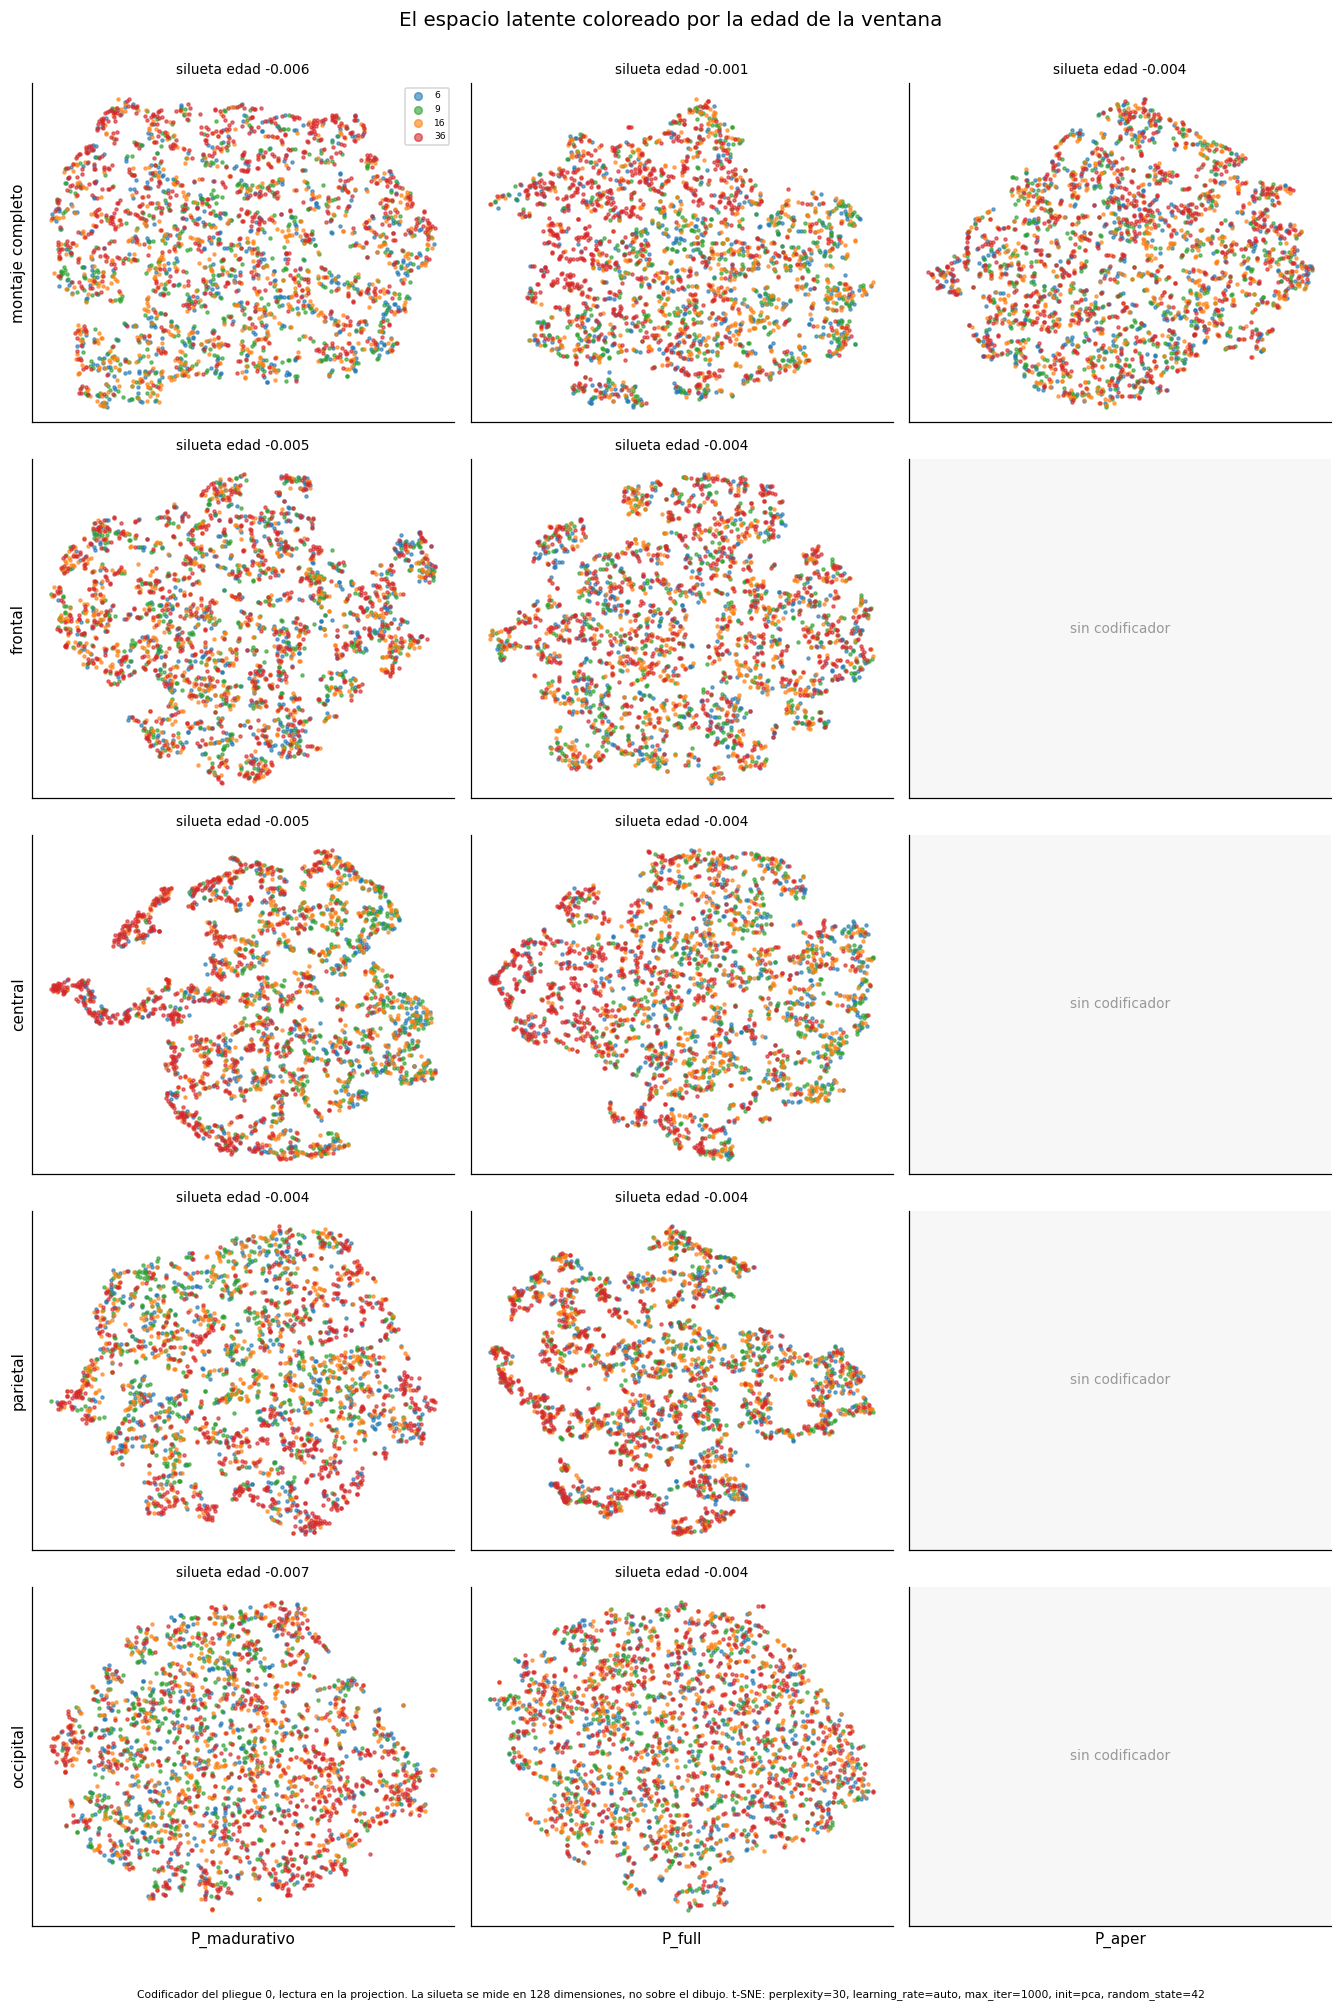

In [8]:
fig = draw_zone_grid(PANELS, "edad", "El espacio latente coloreado por la edad de la ventana",
                     os.path.join(OUT, "rejilla_zonas_edad.png"))
plt.show()

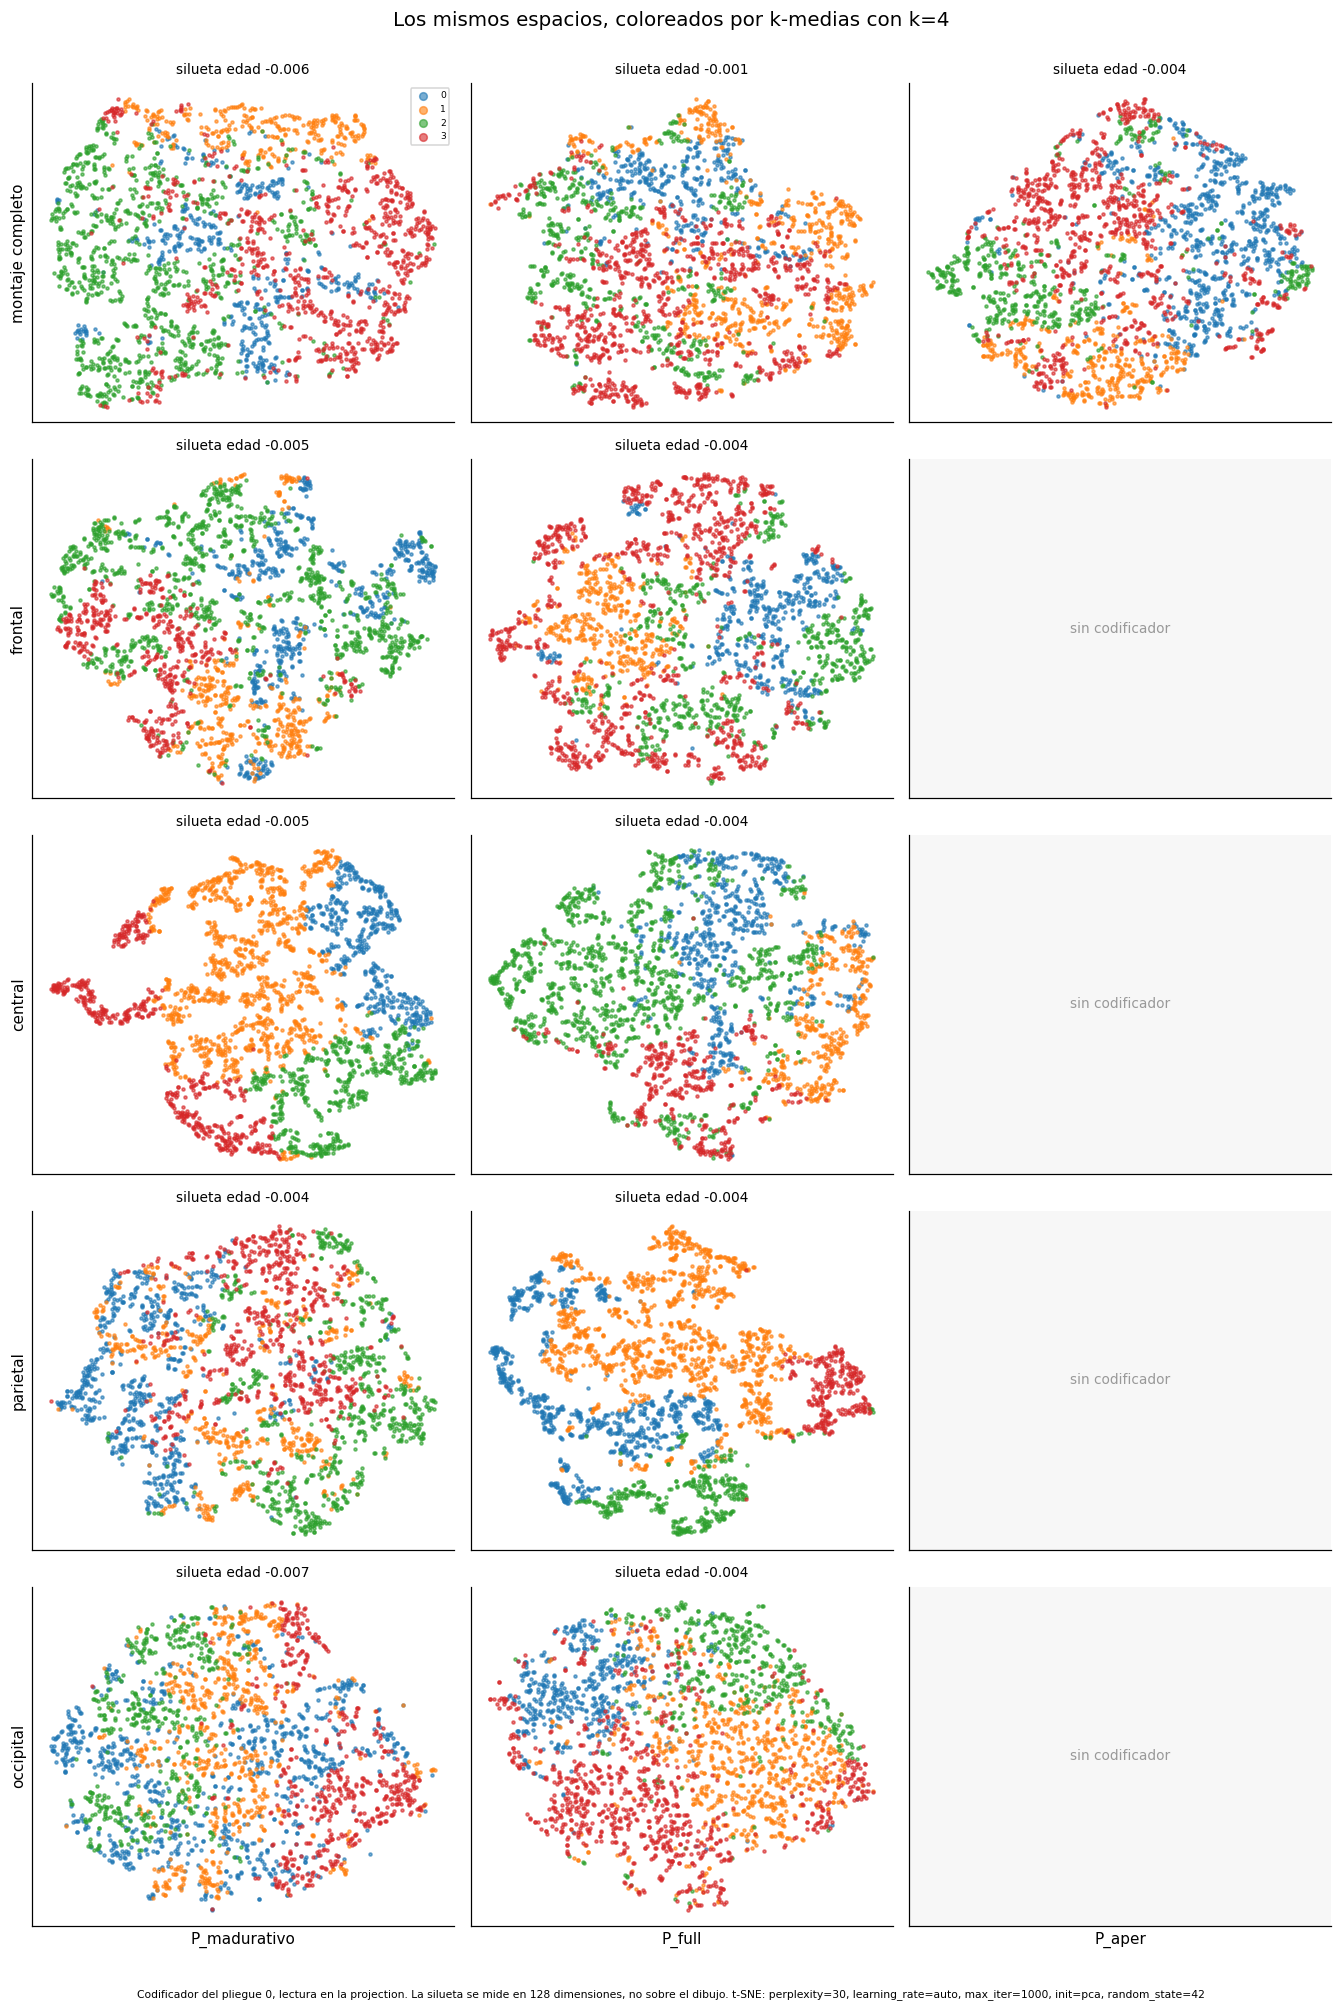

In [9]:
fig = draw_zone_grid(CLUSTERS, "cluster",
                     f"Los mismos espacios, coloreados por k-medias con k={N_CLUSTERS}",
                     os.path.join(OUT, "rejilla_zonas_cluster.png"))
plt.show()

In [10]:
ranking = pd.DataFrame(
    [{"zona": z, "descriptor": d, "columnas": int(
        INVENTORY[(INVENTORY.zona == z) & (INVENTORY.descriptor == d)].columnas.iloc[0]),
      "silueta_edad": s} for (z, d), (_, _, _, s) in PANELS.items()]
).sort_values("silueta_edad", ascending=False)
ranking.to_csv(os.path.join(OUT, "rejilla_silueta_edad.csv"), index=False)
print("Las once combinaciones, por cuanto separan las visitas\n")
print(ranking.round(4).to_string(index=False))
print(f"\nEl rango completo es {ranking.silueta_edad.max() - ranking.silueta_edad.min():.4f}")
print("sobre una escala que va de -1 a 1, y las once son negativas. Ordenar esta columna")
print("sería ordenar ruido; la figura siguiente la dibuja en su escala real.")

Las once combinaciones, por cuanto separan las visitas

     zona   descriptor  columnas  silueta_edad
      all       P_full        78       -0.0012
  central       P_full        19       -0.0036
      all       P_aper         8       -0.0039
occipital       P_full        19       -0.0040
 parietal P_madurativo         8       -0.0042
 parietal       P_full        19       -0.0043
  frontal       P_full        19       -0.0045
  frontal P_madurativo         8       -0.0048
  central P_madurativo         8       -0.0052
      all P_madurativo        32       -0.0065
occipital P_madurativo         8       -0.0072

El rango completo es 0.0060
sobre una escala que va de -1 a 1, y las once son negativas. Ordenar esta columna
sería ordenar ruido; la figura siguiente la dibuja en su escala real.


### 5.4 Las siluetas, en su escala verdadera

Un eje automático sobre valores comprendidos entre -0,0012 y -0,0072 haría parecer que entre
la mejor y la peor media una diferencia de seis veces, cuando en la escala real de la silueta,
que va de -1 a 1, las once combinaciones y sus tres referencias ocupan el mismo punto.

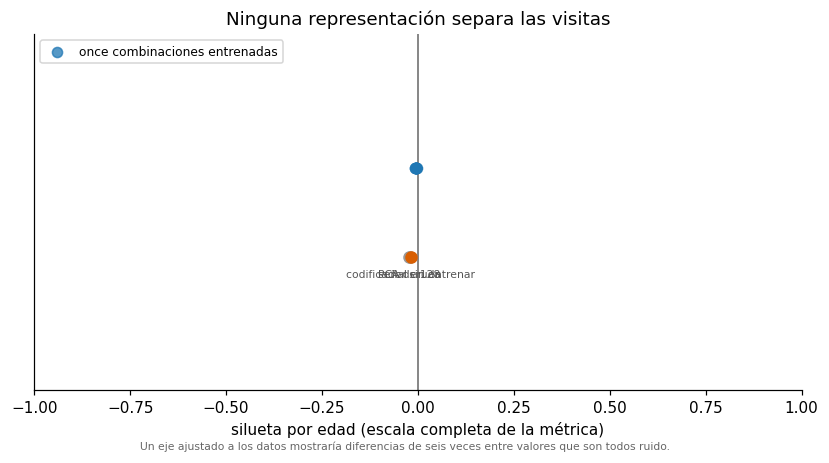

In [11]:
ages_all = meta_all["age"].to_numpy()
CONTROLS = {
    "señal cruda": silhouette_score(raw_space("all", "raw"), ages_all),
    "PCA de 128": silhouette_score(raw_space("all", "pca"), ages_all),
    "codificador sin entrenar": silhouette_score(untrained_space("all"), ages_all),
}

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axvline(0, color="#666666", lw=1)
ax.scatter(ranking.silueta_edad, np.zeros(len(ranking)) + 0.15, s=44, color="#1f77b4",
           alpha=0.75, label="once combinaciones entrenadas", zorder=3)
for (label, value), colour in zip(CONTROLS.items(), ["#999999", "#999999", "#d95f02"]):
    ax.scatter([value], [-0.15], s=52, color=colour, zorder=3)
    ax.annotate(label, (value, -0.15), fontsize=7, xytext=(0, -14),
                textcoords="offset points", ha="center", color="#555555")

ax.set_xlim(-1, 1)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_xlabel("silueta por edad (escala completa de la métrica)")
ax.set_title("Ninguna representación separa las visitas")
ax.legend(fontsize=8, loc="upper left")
fig.text(0.5, -0.02, "Un eje ajustado a los datos mostraría diferencias de seis veces entre "
         "valores que son todos ruido.", ha="center", fontsize=7, color="#666666")
fig.savefig(os.path.join(OUT, "siluetas_escala_real.png"))
plt.show()

## 6. La señal cruda frente a la representación aprendida

Esta sección enfrenta tres espacios con la misma proyección y el mismo coloreado, la señal
aplanada tal cual, su reducción por componentes principales a 128 dimensiones y la combinación
de ExpCLR que ilustra el cuaderno, con el fin de aislar qué añade el codificador por encima
del material del que parte.

A esos tres se suma una cuarta referencia que suele omitirse, el mismo codificador sin
entrenar. Una pila convolucional con pesos aleatorios ya resulta selectiva, por lo que parte
de cualquier geometría observada procede de la arquitectura y no de lo que la pérdida haya
enseñado, y sin esa referencia no hay manera de repartir el mérito entre las dos.

La que mejor separa las visitas: P_full sobre montaje completo (silueta -0.0012)
La que ilustra estas figuras:    ExpCLR sobre montaje completo

No son la misma. La sección 7 mide por qué: la silueta no anticipa el rendimiento.
Esta sección no elige nada; el corte entre las once llega en la sección 10.


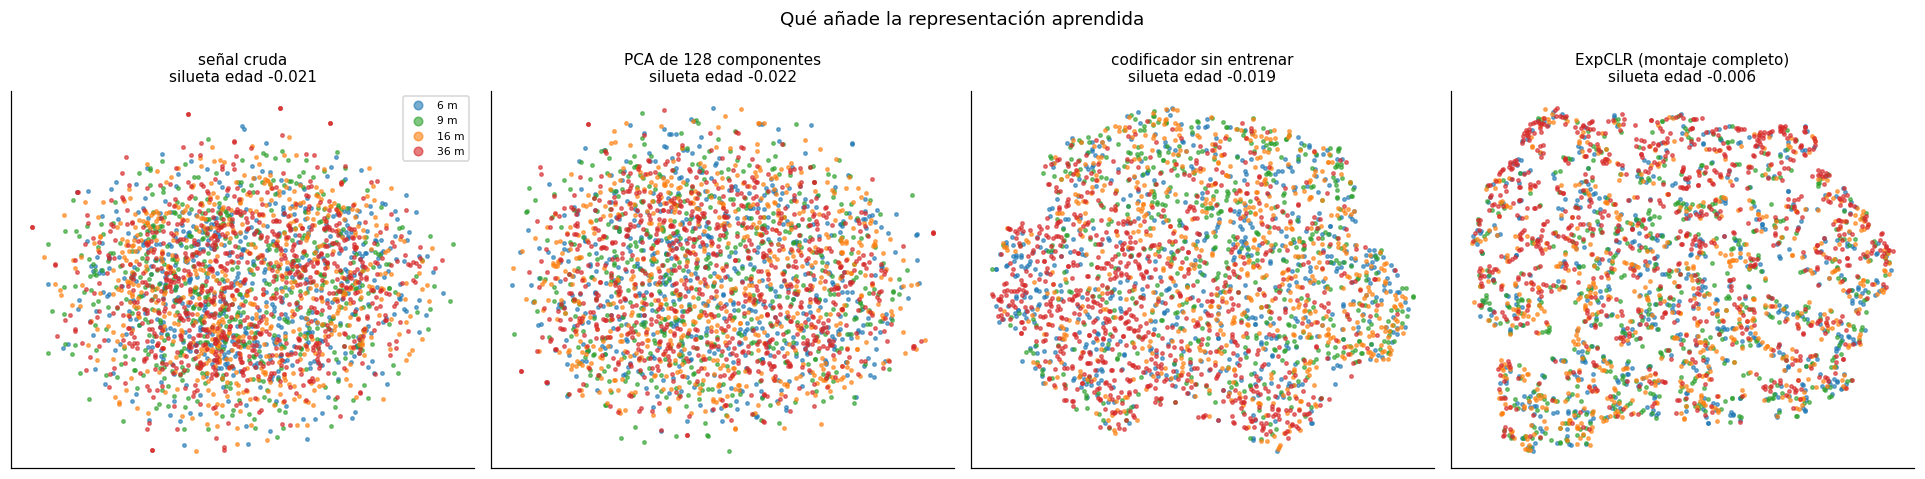

                  espacio  dimensiones  silueta_edad
              señal cruda        87500       -0.0206
   PCA de 128 componentes          128       -0.0219
 codificador sin entrenar          128       -0.0189
ExpCLR (montaje completo)          128       -0.0065


In [12]:
best_by_silhouette = ranking.iloc[0]
print(f"La que mejor separa las visitas: {best_by_silhouette.descriptor} sobre "
      f"{ZONE_LABEL[best_by_silhouette.zona]} (silueta {best_by_silhouette.silueta_edad:+.4f})")
print(f"La que ilustra estas figuras:    {ILLUSTRATED[0]} sobre "
      f"{ZONE_LABEL[ILLUSTRATED[1]]}")
print("\nNo son la misma. La sección 7 mide por qué: la silueta no anticipa el rendimiento.")
print("Esta sección no elige nada; el corte entre las once llega en la sección 10.")

comparison = {
    "señal cruda": raw_space("all", "raw"),
    "PCA de 128 componentes": raw_space("all", "pca"),
    "codificador sin entrenar": untrained_space("all"),
    f"{ILLUSTRATED[0]} ({ZONE_LABEL[ILLUSTRATED[1]]})": SPACES[ILLUSTRATED][0],
}
ages = SPACES[ILLUSTRATED][1]["age"].to_numpy()

fig, axes = plt.subplots(1, len(comparison), figsize=(4.4 * len(comparison), 4.4))
rows = []
for ax, (name, Z) in zip(axes, comparison.items()):
    coords = projection_of(name.replace(" ", "_").replace("(", "").replace(")", ""), Z)
    for age in AGES:
        mask = ages == age
        ax.scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.6,
                   color=AGE_COLOURS[age], label=f"{age} m")
    score = silhouette_score(Z, ages)
    ax.set_title(f"{name}\nsilueta edad {score:+.3f}", fontsize=10)
    ax.set_xticks([]), ax.set_yticks([])
    rows.append({"espacio": name, "dimensiones": Z.shape[1], "silueta_edad": score})
axes[0].legend(fontsize=7, markerscale=2.5)
fig.suptitle("Qué añade la representación aprendida", fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "crudo_frente_representacion.png"))
plt.show()

CRUDO = pd.DataFrame(rows)
CRUDO.to_csv(os.path.join(OUT, "crudo_frente_representacion.csv"), index=False)
print(CRUDO.round(4).to_string(index=False))

## 7. Qué separan los clústeres

Donde la rejilla enseña formas, esta sección describe el contenido de cada grupo mediante dos
medidas por combinación, el reparto de sus cuatro clústeres entre las visitas y el grado en
que las ventanas de un mismo niño se concentran en un solo grupo.

Ambas medidas responden a las dos únicas preguntas que un clúster puede contestar con este
material, esto es, si el grupo corresponde a una visita o si corresponde a un niño. Un clúster
que no sea ninguna de las dos cosas estará separando algo que este cuaderno no puede
nombrar.

In [13]:
rows = []
for (zone, descriptor), (_, labels, _, _) in CLUSTERS.items():
    method = VARIANT_OF[descriptor]
    meta = SPACES[(method, zone)][1]
    frame = meta.assign(cluster=labels)

    by_age = pd.crosstab(frame.cluster, frame.age, normalize="index")
    dominant_age = by_age.max(axis=1)
    by_subject = pd.crosstab(frame.subject, frame.cluster, normalize="index")
    dominant_subject = by_subject.max(axis=1)

    # El azar de cada panel, calculado por combinación y no supuesto. Para la pureza de
    # visita es la prevalencia de la visita mayoritaria, porque un clúster formado al azar
    # reproduce la distribución de la población. Para la concentración por niño es el tamaño
    # relativo del clúster mayor. Ninguno de los dos es 1/k.
    rows.append({
        "zona": zone, "descriptor": descriptor,
        "pureza_visita_media": dominant_age.mean(),
        "azar_visita": float(frame.age.value_counts(normalize=True).max()),
        "pureza_visita_max": dominant_age.max(),
        "concentracion_nino_mediana": dominant_subject.median(),
        "azar_nino": float(frame.cluster.value_counts(normalize=True).max()),
        "ninos_en_un_solo_grupo": int((dominant_subject > 0.8).sum()),
    })

COMPOSITION = pd.DataFrame(rows).sort_values("pureza_visita_media", ascending=False)
COMPOSITION.to_csv(os.path.join(OUT, "composicion_clusteres.csv"), index=False)
print("Qué hay dentro de los clústeres de cada combinación\n")
print(COMPOSITION.round(3).to_string(index=False))
# El azar de la pureza del clúster dominante NO es 1/k: un clúster formado al azar reproduce
# la distribución de la población, y su máximo es la prevalencia de la visita mayoritaria.
# Las cuatro visitas no están repartidas en cuartos: la de 36 meses es el 32,6 % de las
# ventanas. Marcar 0,25 haría pasar por encima del azar a combinaciones que están en él.
VISIT_CHANCE = float(COMPOSITION.azar_visita.median())
CHILD_CHANCE = float(COMPOSITION.azar_nino.median())
sobre_azar = int((COMPOSITION.pureza_visita_media > COMPOSITION.azar_visita).sum())
print("\npureza_visita: fracción de la visita dominante dentro de cada clúster, promediada.")
print(f"  El azar es la prevalencia de la visita mayoritaria, {VISIT_CHANCE:.3f}, no 0,25.")
print(f"  Combinaciones por encima de su propio azar: {sobre_azar} de {len(COMPOSITION)}.")
print("concentracion_nino: fraccion de las ventanas de un niño en su clúster dominante.")
print(f"  El azar es el tamaño relativo del clúster mayor, {CHILD_CHANCE:.3f}; "
      "cerca de 1 significa huella individual.")

Qué hay dentro de los clústeres de cada combinación

     zona   descriptor  pureza_visita_media  azar_visita  pureza_visita_max  concentracion_nino_mediana  azar_nino  ninos_en_un_solo_grupo
      all       P_full                0.419        0.326              0.626                       0.435      0.374                       0
  central P_madurativo                0.407        0.326              0.600                       0.504      0.436                       0
 parietal P_madurativo                0.382        0.326              0.543                       0.360      0.286                       0
      all P_madurativo                0.371        0.326              0.584                       0.424      0.390                       0
occipital P_madurativo                0.361        0.326              0.472                       0.382      0.345                       0
 parietal       P_full                0.347        0.326              0.430                       0.462      0.46

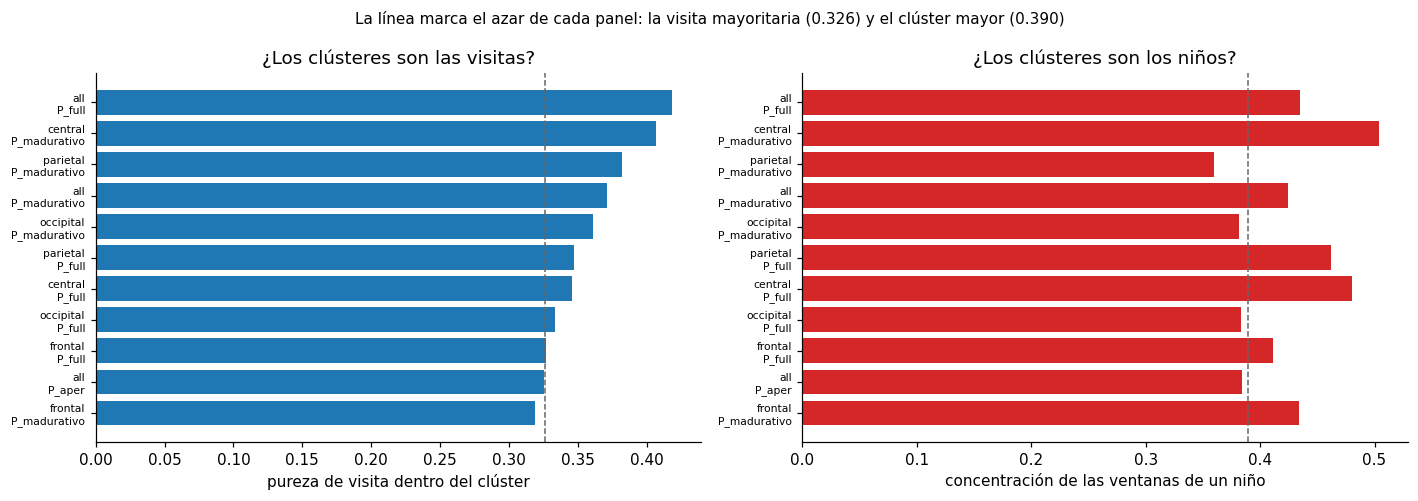

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
order = COMPOSITION.assign(etiqueta=lambda d: d.zona + "\n" + d.descriptor)

axes[0].barh(range(len(order)), order.pureza_visita_media, color="#1f77b4")
axes[0].axvline(VISIT_CHANCE, ls="--", lw=1, color="#666666")
axes[0].set_yticks(range(len(order)), order.etiqueta, fontsize=7)
axes[0].set_xlabel("pureza de visita dentro del clúster")
axes[0].set_title("¿Los clústeres son las visitas?")
axes[0].invert_yaxis()

axes[1].barh(range(len(order)), order.concentracion_nino_mediana, color="#d62728")
axes[1].axvline(CHILD_CHANCE, ls="--", lw=1, color="#666666")
axes[1].set_yticks(range(len(order)), order.etiqueta, fontsize=7)
axes[1].set_xlabel("concentración de las ventanas de un niño")
axes[1].set_title("¿Los clústeres son los niños?")
axes[1].invert_yaxis()

fig.suptitle(f"La línea marca el azar de cada panel: la visita mayoritaria "
             f"({VISIT_CHANCE:.3f}) y el clúster mayor ({CHILD_CHANCE:.3f})", fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "composicion_clusteres.png"))
plt.show()

## 8. La huella de cada niño

Con una barra por niño y el reparto de sus ventanas entre los clústeres, la figura trabaja
sobre la combinación que ilustra el cuaderno, y detalla así la columna derecha de la figura
anterior.

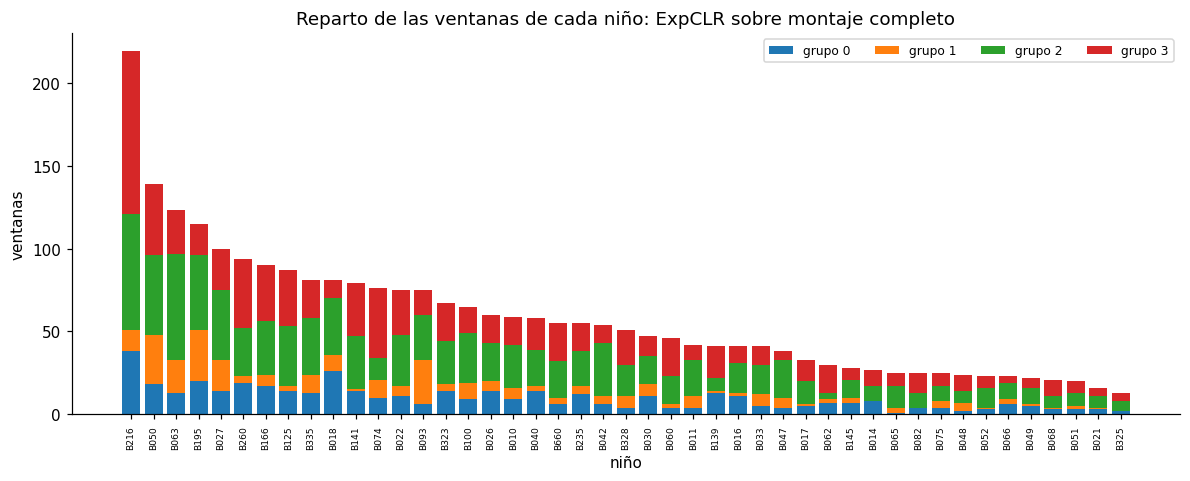


mediana de concentración: 0.42  |  niños con más del 80 % en un grupo: 0 de 45


In [15]:
Z_best, meta_best = SPACES[ILLUSTRATED]
labels_best = latent_map.fit_clusters(Z_best, N_CLUSTERS).labels_
share = pd.crosstab(meta_best.subject, labels_best)
share = share.loc[share.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 4.5))
bottom = np.zeros(len(share))
for cluster in share.columns:
    ax.bar(range(len(share)), share[cluster].values, bottom=bottom, label=f"grupo {cluster}")
    bottom += share[cluster].values
ax.set_xticks(range(len(share)), share.index, rotation=90, fontsize=6)
ax.set_xlabel("niño"), ax.set_ylabel("ventanas")
ax.set_title(f"Reparto de las ventanas de cada niño: {ILLUSTRATED[0]} sobre "
             f"{ZONE_LABEL[ILLUSTRATED[1]]}")
ax.legend(fontsize=8, ncols=4)
fig.savefig(os.path.join(OUT, "huella_sujeto.png"))
plt.show()

dominant = share.div(share.sum(axis=1), axis=0).max(axis=1)
print(f"\nmediana de concentración: {dominant.median():.2f}  |  "
      f"niños con más del 80 % en un grupo: {(dominant > 0.8).sum()} de {len(dominant)}")

## 9. La tarea posterior

La tabla recoge el error absoluto medio en meses, calculado sobre sesiones, fuera de pliegue y
con intervalo obtenido por remuestreo de niños. Las referencias que no usan el EEG figuran
dentro de la propia tabla y como líneas verticales en la figura, ya que una combinación
situada a su derecha no habrá demostrado nada.

Entre esas referencias está el predictor de identidad, que asigna a cada sesión la media de
edad de las visitas de su propio niño. Una combinación que no lo supere habrá aprendido a
reconocer al niño y a devolver su edad típica, sin que la señal aporte nada por encima de esa
identificación.

In [16]:
def trivial_references(sessions):
    """Returns the error of predictors that use no EEG at all.

    Args:
        sessions (pd.DataFrame): One row per session, with ``y_true`` and ``subject``.

    Returns:
        pd.DataFrame: One row per reference, with MAE and R2.
    """
    y = sessions["y_true"].to_numpy(float)
    rows = []

    def record(name, pred):
        ss_res = float(np.sum((y - pred) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        rows.append({"referencia": name, "mae": float(np.mean(np.abs(y - pred))),
                     "r2": 1 - ss_res / ss_tot})

    # The headline metric is the MAE, and the constant that minimises the MAE is the median,
    # not the mean. With this cohort the difference decides whether there is a result at all:
    # the mean sits at 15.65 months and scores 9.076, the median at 9 months and scores 8.445.
    # Comparing against the mean sets the bar 0.63 months too low. Both are reported, and the
    # median is the one the figure uses as the frontier.
    record("constante (media global)", np.full_like(y, y.mean()))
    record("constante (mediana global)", np.full_like(y, np.median(y)))
    is_last = y == 36
    record("oráculo: solo la visita de 36 m",
           np.where(is_last, np.median(y[is_last]), np.median(y[~is_last])))
    record("predictor de identidad",
           sessions.groupby("subject")["y_true"].transform("mean").to_numpy())
    record("oráculo: todo salvo 6 frente a 9",
           np.where(np.isin(y, [6, 9]), np.mean([6, 9]), y))
    return pd.DataFrame(rows)


TRIVIAL = trivial_references(reference["sessions"])
TRIVIAL.to_csv(os.path.join(OUT, "referencias_triviales.csv"), index=False)

rows = []
for (method, zone), result in RESULTS.items():
    for probe_name, frame in [("lineal", result["sessions"]), ("kNN", result["sessions_knn"])]:
        low, high = bootstrap_ci(frame, "mae")
        rows.append({"metodo": method, "zona": zone, "sonda": probe_name,
                     **session_metrics(frame), "mae_ic_bajo": low, "mae_ic_alto": high,
                     **subject_metrics(frame)})
PERFORMANCE = pd.DataFrame(rows).sort_values("mae")
PERFORMANCE.to_csv(os.path.join(OUT, "rendimiento.csv"), index=False)

view = PERFORMANCE[PERFORMANCE.sonda == "lineal"][
    ["metodo", "zona", "n_sessions", "mae", "mae_ic_bajo", "mae_ic_alto", "r2", "rho"]]
print("Sonda lineal, sobre sesiones, ordenado por MAE\n")
print(view.round(3).to_string(index=False))
print("\nReferencias que no usan el EEG\n")
print(TRIVIAL.round(3).to_string(index=False))

Sonda lineal, sobre sesiones, ordenado por MAE

     metodo      zona  n_sessions    mae  mae_ic_bajo  mae_ic_alto     r2   rho
     ExpCLR       all         274  7.797        6.969        8.593  0.296 0.401
     ExpCLR  parietal         274  8.372        7.756        9.004  0.208 0.324
ExpCLR-full  parietal         274  9.262        8.675        9.892  0.094 0.211
     ExpCLR   central         274  9.369        8.758        9.922  0.073 0.213
ExpCLR-full   central         274  9.559        8.969       10.103  0.050 0.260
ExpCLR-full       all         274  9.728        9.079       10.353  0.021 0.157
     ExpCLR occipital         274  9.925        9.375       10.433  0.015 0.274
ExpCLR-aper       all         274 10.235        9.731       10.710 -0.014 0.258
ExpCLR-full occipital         274 10.254        9.712       10.758 -0.027 0.174
     ExpCLR   frontal         274 10.358        9.831       10.870 -0.024 0.228
ExpCLR-full   frontal         274 10.624       10.115       11.132 -0.08

### 9.1 La escalera completa

La figura reúne todas las referencias en un solo eje expresado en meses y con origen en cero.
Los predictores que no usan el EEG y el descriptor experto sin codificador se dibujan dentro
de la figura y no como líneas al margen, ya que son ellos los que dan escala al resto.

Dentro de la figura, la banda gris marca la región peor que la mejor constante, que para el
error absoluto medio es
la mediana y no la media, y una combinación que caiga dentro de esa banda no habrá demostrado
nada.

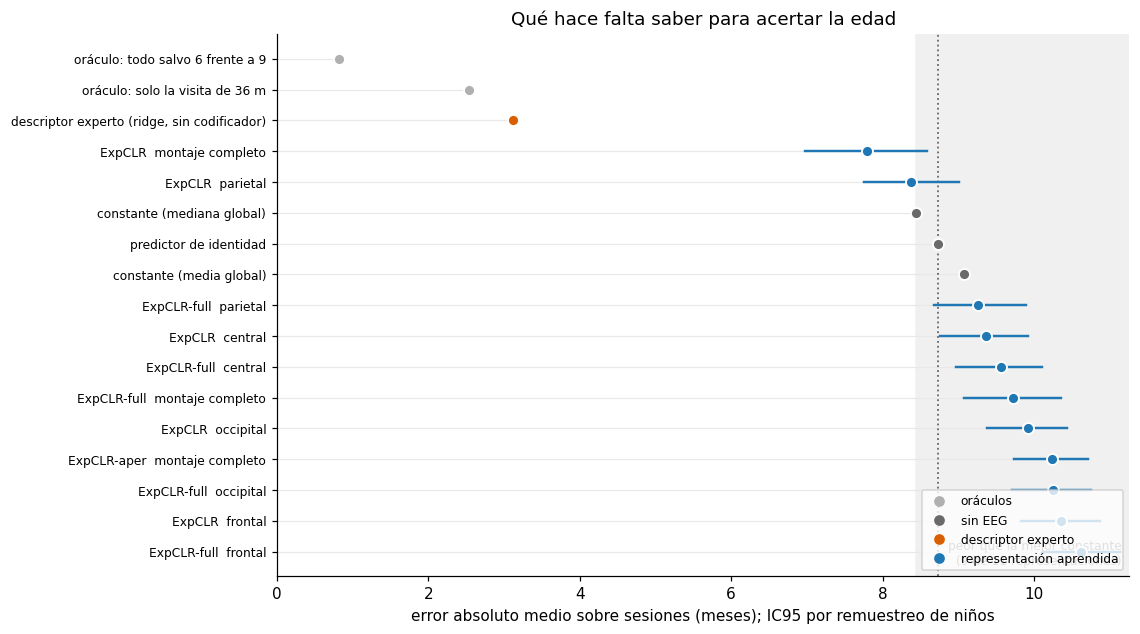

El descriptor experto (3.125) frente al oráculo que solo detecta la visita de 36 meses (2.533):
  no lo supera. Su rendimiento es compatible con detectar unicamente esa visita.


In [17]:
from build_expert_features import descriptor_path, zone_dir            # noqa: E402
from tabular_baseline import impute_with_train_medians                 # noqa: E402


def descriptor_probe(zone, descriptor):
    """Regresses the expert descriptor with no encoder, fold by fold.

    This is the reference the whole chapter hangs on: if the encoder does not beat the
    descriptor it was guided by, the contrastive stage subtracted information. It is computed
    here rather than in the contrast section because the ladder needs it.

    Args:
        zone (str): Head zone.
        descriptor (str): Descriptor name.

    Returns:
        pd.DataFrame | None: Out-of-fold predictions aggregated to session.

    Raises:
        ValueError: If the descriptor and the windows describe different datasets.
    """
    cached = os.path.join(CACHE, f"descriptor_{zone}_{descriptor}.csv")
    if os.path.exists(cached):
        return pd.read_csv(cached, dtype={"subject": str})

    path = descriptor_path(descriptor, zone_dir(zone))
    if not os.path.exists(path):
        return None
    F = np.load(path)
    _, meta = load_zone(zone)
    if len(F) != len(meta):
        raise ValueError(f"{path}: {len(F)} filas para {len(meta)} ventanas.")

    subjects = meta["subject"].to_numpy()
    y = meta["age"].to_numpy(float)
    out = []
    for held_out in canonical_subject_folds(sorted(np.unique(subjects)), N_FOLDS, BASE_SEED):
        test = np.isin(subjects, held_out)
        train = ~test
        filled, _ = impute_with_train_medians(F, train)
        scaler, probe = fit_probe(filled[train], y[train], subjects[train])
        out.append(aggregate_to_sessions(
            meta[test], y[test], probe.predict(scaler.transform(filled[test]))))
    predictions = pd.concat(out, ignore_index=True)
    predictions.to_csv(cached, index=False)
    return predictions


B1 = descriptor_probe("all", "P_madurativo")
best_mae = session_metrics(RESULTS[ILLUSTRATED]["sessions"])["mae"]
descriptor_mae = session_metrics(B1)["mae"] if B1 is not None else None

GREY, TRIVIAL_C, EXPERT_C, LEARNED_C = "#b0b0b0", "#6a6a6a", "#d95f02", "#1f77b4"
ladder = []
for _, row in TRIVIAL.iterrows():
    kind = "oráculo" if row.referencia.startswith("oráculo") else "trivial"
    ladder.append({"nombre": row.referencia, "mae": row.mae, "clase": kind,
                   "bajo": np.nan, "alto": np.nan})
if descriptor_mae is not None:
    ladder.append({"nombre": "descriptor experto (ridge, sin codificador)",
                   "mae": descriptor_mae, "clase": "experto", "bajo": np.nan, "alto": np.nan})
for _, row in PERFORMANCE[PERFORMANCE.sonda == "lineal"].iterrows():
    ladder.append({"nombre": f"{row.metodo}  {ZONE_LABEL[row.zona]}", "mae": row.mae,
                   "clase": "aprendida", "bajo": row.mae_ic_bajo, "alto": row.mae_ic_alto})
LADDER = pd.DataFrame(ladder).sort_values("mae").reset_index(drop=True)
LADDER.to_csv(os.path.join(OUT, "escalera.csv"), index=False)

colours = {"oráculo": GREY, "trivial": TRIVIAL_C, "experto": EXPERT_C, "aprendida": LEARNED_C}
# La frontera de "no ha demostrado nada" es la constante que minimiza la métrica principal,
# y para el MAE esa constante es la mediana, no la media. Usar la media pone el listón
# 0,63 meses más abajo y regala esa distancia a cualquier combinación.
constant = float(TRIVIAL.set_index("referencia").mae["constante (mediana global)"])
identity = float(TRIVIAL.set_index("referencia").mae["predictor de identidad"])

fig, ax = plt.subplots(figsize=(10, 6.4))
ax.axvspan(constant, LADDER.mae.max() * 1.06, color="#f0f0f0", zorder=0)
ax.text(LADDER.mae.max() * 1.05, len(LADDER) - 0.5,
        f"peor que la mejor constante\n"
        f"({int((LADDER[LADDER.clase == 'aprendida'].mae > constant).sum())} de "
        f"{int((LADDER.clase == 'aprendida').sum())} representaciones)",
        ha="right", va="bottom", fontsize=8, color="#666666")

for i, row in LADDER.iterrows():
    ax.plot([0, row.mae], [i, i], color="#e8e8e8", lw=0.8, zorder=1)
    if np.isfinite(row.bajo):
        ax.plot([row.bajo, row.alto], [i, i], color=colours[row.clase], lw=1.6, zorder=2)
    ax.scatter(row.mae, i, s=52, color=colours[row.clase], zorder=3,
               edgecolor="white", linewidth=1.2)
ax.axvline(identity, ls=":", lw=1.2, color=TRIVIAL_C, zorder=1)

ax.set_yticks(range(len(LADDER)), LADDER.nombre, fontsize=8)
ax.set_xlim(0, LADDER.mae.max() * 1.06)
ax.set_xlabel("error absoluto medio sobre sesiones (meses); IC95 por remuestreo de niños")
ax.set_title("Qué hace falta saber para acertar la edad")
ax.invert_yaxis()

handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=l) for c, l in
           [(GREY, "oráculos"), (TRIVIAL_C, "sin EEG"), (EXPERT_C, "descriptor experto"),
            (LEARNED_C, "representación aprendida")]]
ax.legend(handles=handles, fontsize=8, loc="lower right")
fig.savefig(os.path.join(OUT, "escalera.png"))
plt.show()

if descriptor_mae is not None:
    oraculo36 = float(TRIVIAL.set_index("referencia").mae["oráculo: solo la visita de 36 m"])
    print(f"El descriptor experto ({descriptor_mae:.3f}) frente al oráculo que solo detecta "
          f"la visita de 36 meses ({oraculo36:.3f}):")
    print(f"  {'no lo supera' if descriptor_mae > oraculo36 else 'lo supera'}. Su rendimiento "
          "es compatible con detectar unicamente esa visita.")

### 9.2 La compresión

El sesgo por visita se lee ya en la figura anterior como la distancia vertical de cada nube a
la diagonal, sin necesidad de un panel propio. Hace falta en cambio un número que resuma
cuánto se mueve la predicción, y ese número es la pendiente de lo predicho sobre lo real, que
en un predictor sin encogimiento valdría 1.

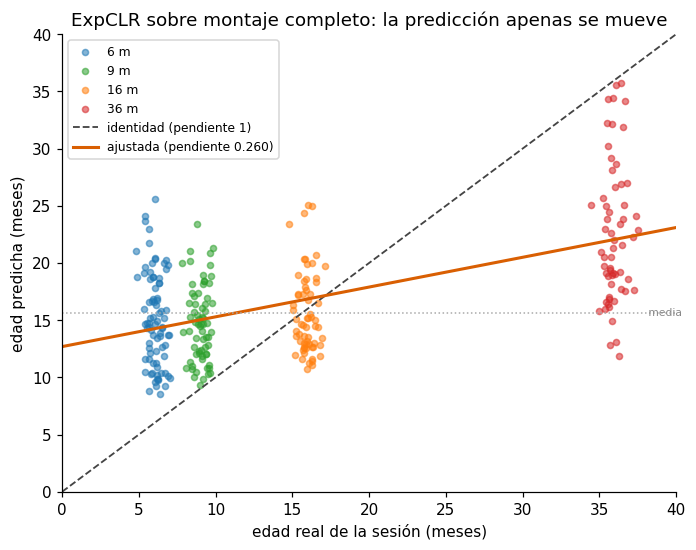

Cuánto se mueve la predicción en las once combinaciones

     metodo      zona  pendiente  rango_predicho  rango_real
     ExpCLR       all      0.260           6.845        30.0
     ExpCLR  parietal      0.193           5.540        30.0
ExpCLR-full  parietal      0.110           3.337        30.0
ExpCLR-full   central      0.098           3.933        30.0
     ExpCLR   central      0.091           3.364        30.0
ExpCLR-full       all      0.075           2.303        30.0
     ExpCLR occipital      0.063           2.365        30.0
ExpCLR-aper       all      0.044           1.553        30.0
ExpCLR-full occipital      0.037           0.956        30.0
     ExpCLR   frontal      0.035           0.734        30.0
ExpCLR-full   frontal      0.002           0.224        30.0

La pendiente ideal es 1. La mejor alcanza 0.260 y la peor
0.002: esa ultima es, a efectos prácticos, una constante.

 age  n    mae    bias  pred_median metodo zona
   6 82  9.110   9.110       14.692 ExpCLR  a

In [18]:
best_sessions = RESULTS[ILLUSTRATED]["sessions"]
slope, intercept = np.polyfit(best_sessions.y_true, best_sessions.y_pred, 1)

fig, ax = plt.subplots(figsize=(7.2, 5.4))
rng = np.random.default_rng(0)
for age in AGES:
    sel = best_sessions.y_true == age
    ax.scatter(best_sessions.y_true[sel] + rng.normal(0, 0.5, int(sel.sum())),
               best_sessions.y_pred[sel], s=16, alpha=0.55, color=AGE_COLOURS[age],
               label=f"{age} m")
grid = np.array([0, 40])
ax.plot(grid, grid, ls="--", lw=1.2, color="#444444", label="identidad (pendiente 1)")
ax.plot(grid, intercept + slope * grid, lw=2, color="#d95f02",
        label=f"ajustada (pendiente {slope:.3f})")
ax.axhline(best_sessions.y_true.mean(), lw=1, color="#aaaaaa", ls=":")
ax.text(38, best_sessions.y_true.mean(), " media", fontsize=7, color="#888888", va="center")
ax.set_xlim(0, 40), ax.set_ylim(0, 40)
ax.set_xlabel("edad real de la sesión (meses)")
ax.set_ylabel("edad predicha (meses)")
ax.set_title(f"{ILLUSTRATED[0]} sobre {ZONE_LABEL[ILLUSTRATED[1]]}: la predicción apenas se mueve")
ax.legend(fontsize=8, loc="upper left")
fig.savefig(os.path.join(OUT, "compresión.png"))
plt.show()

rows = []
for (method, zone), result in RESULTS.items():
    s = result["sessions"]
    medians = s.groupby("age").y_pred.median()
    rows.append({"metodo": method, "zona": zone,
                 "pendiente": float(np.polyfit(s.y_true, s.y_pred, 1)[0]),
                 "rango_predicho": float(medians.max() - medians.min()),
                 "rango_real": float(s.y_true.max() - s.y_true.min())})
COMPRESSION = pd.DataFrame(rows).sort_values("pendiente", ascending=False)
COMPRESSION.to_csv(os.path.join(OUT, "compresión.csv"), index=False)
print("Cuánto se mueve la predicción en las once combinaciones\n")
print(COMPRESSION.round(3).to_string(index=False))
print(f"\nLa pendiente ideal es 1. La mejor alcanza {COMPRESSION.pendiente.max():.3f} y la peor")
print(f"{COMPRESSION.pendiente.min():.3f}: esa ultima es, a efectos prácticos, una constante.")

by_visit = metrics_by_visit(best_sessions).assign(metodo=ILLUSTRATED[0], zona=ILLUSTRATED[1])
by_visit.to_csv(os.path.join(OUT, "error_por_visita.csv"), index=False)
print("\n" + by_visit.round(3).to_string(index=False))

### 9.3 Por qué el espacio no agrupa y aun así predice

Las dos afirmaciones del título solo parecen contradictorias. La silueta pondera por igual las
128 dimensiones del espacio, mientras la dirección que la sonda utiliza para predecir ocupa
una fracción mínima de la varianza de un espacio cuya dimensión efectiva ronda 40, con lo cual
una señal que explique poca varianza global resulta invisible para una métrica isótropa y sigue
siendo utilizable por una proyección lineal aprendida sobre esos mismos datos.

Sobre el mismo conjunto de puntos trabajan los dos paneles de la figura, a la izquierda tal
como los ve la silueta y a la derecha proyectados sobre la dirección de la sonda.

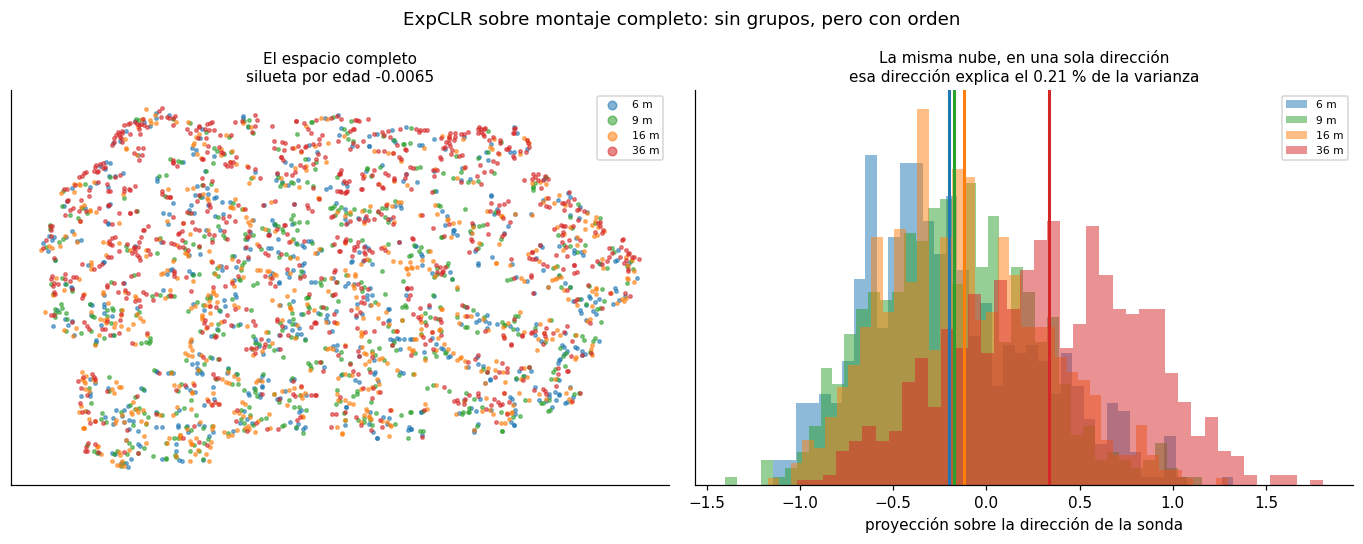

Media de la proyección por visita:
6    -0.199
9    -0.173
16   -0.117
36    0.334

¿Están ordenadas con la edad? si
La dirección explica el 0.21 % de la varianza del espacio: por eso la
silueta, que pondera por igual las 128 dimensiones, no alcanza a recogerla.


In [19]:
Z_best_space, meta_best_space = SPACES[ILLUSTRATED]
X_best, meta_zone = load_zone(ILLUSTRATED[1])
subjects_best = meta_zone["subject"].to_numpy()
y_best = meta_zone["age"].to_numpy(float)

# The probe direction, fitted on the whole cohort: this panel describes the geometry of the
# space, not out-of-fold performance, which section 10.1 already reported.
scaler_all, probe_all = fit_probe(Z_best_space, y_best, subjects_best)
direction = probe_all.coef_ / np.linalg.norm(probe_all.coef_)
scores = scaler_all.transform(Z_best_space) @ direction

# La dirección de la sonda es unitaria en las coordenadas estandarizadas, que es donde la
# ridge la ajustó, así que la fracción de varianza se mide ahí y no en el espacio sin
# estandarizar: proyectar sobre una dirección que no es unitaria en ese otro espacio, y
# dividir por su varianza total, mezcla numerador y denominador de sistemas distintos y no
# produce una fracción de nada. Cada dimensión estandarizada tiene varianza uno, de modo que
# la varianza total del espacio es su número de dimensiones.
standardised = scaler_all.transform(Z_best_space)
share = float(np.var(scores) / standardised.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
coords_best = projection_of(f"{ILLUSTRATED[0]}_{ILLUSTRATED[1]}", Z_best_space)
for age in AGES:
    sel = y_best == age
    axes[0].scatter(coords_best[sel, 0], coords_best[sel, 1], s=5, alpha=0.55,
                    color=AGE_COLOURS[age], label=f"{age} m")
axes[0].set_xticks([]), axes[0].set_yticks([])
axes[0].set_title(f"El espacio completo\nsilueta por edad "
                  f"{silhouette_score(Z_best_space, y_best):+.4f}", fontsize=10)
axes[0].legend(fontsize=7, markerscale=2.5)

for age in AGES:
    sel = y_best == age
    axes[1].hist(scores[sel], bins=40, alpha=0.5, color=AGE_COLOURS[age],
                 label=f"{age} m", density=True)
for age in AGES:
    axes[1].axvline(scores[y_best == age].mean(), color=AGE_COLOURS[age], lw=2)
axes[1].set_xlabel("proyección sobre la dirección de la sonda")
axes[1].set_yticks([])
axes[1].set_title(f"La misma nube, en una sola dirección\nesa dirección explica el "
                  f"{100 * share:.2f} % de la varianza", fontsize=10)
axes[1].legend(fontsize=7)

fig.suptitle(f"{ILLUSTRATED[0]} sobre {ZONE_LABEL[ILLUSTRATED[1]]}: sin grupos, pero con orden", fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "tension_grupos_gradiente.png"))
plt.show()

means = pd.Series({age: scores[y_best == age].mean() for age in AGES})
print("Media de la proyección por visita:")
print(means.round(3).to_string())
print(f"\n¿Están ordenadas con la edad? {'si' if means.is_monotonic_increasing or means.is_monotonic_decreasing else 'no'}")
print(f"La dirección explica el {100 * share:.2f} % de la varianza del espacio: por eso la")
print("silueta, que pondera por igual las 128 dimensiones, no alcanza a recogerla.")

### 9.4 Dos sondas y dos unidades

La figura enfrenta la sonda lineal con la de vecino más próximo, ya que la información
debería favorecer a la segunda si viviera en la vecindad local del espacio, que es lo que un
objetivo contrastivo optimiza. El segundo panel recoge qué le ocurre a cada combinación cuando
la evaluación se agrega por niño en lugar de por sesión.

Las dos sondas se ajustan bajo el mismo protocolo. La lineal elige su alfa entre treinta
valores con validación agrupada por sujeto, y la de vecino elige su k entre cinco tamaños de
vecindario con esa misma validación, ya que dejarla en el k igual a uno del repositorio la
enfrentaría a un rival ajustado con un estimador de varianza máxima que además solo puede
devolver las cuatro edades que vio. La subsección siguiente recorre la rejilla completa de k
para comprobar que la conclusión no depende del valor elegido.

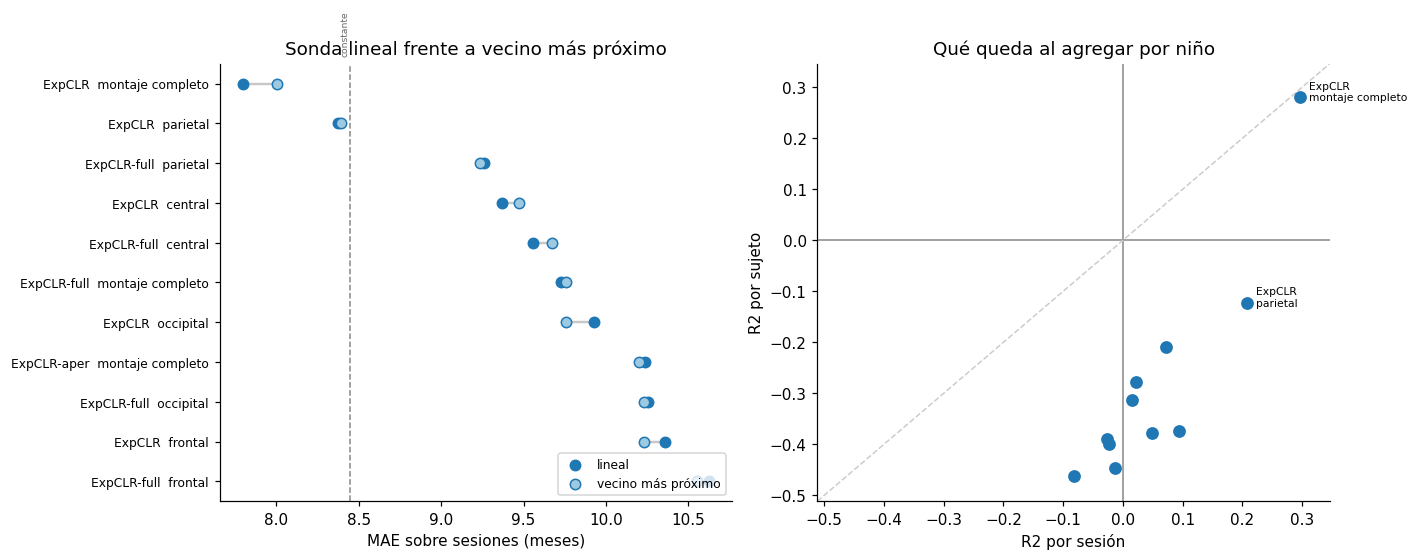

R2 positivo por sesión: 7 de 11
R2 positivo por sujeto: 1 de 11
nRMSE por sujeto mayor que 1 (peor que la desviación típica): 10 de 11

La sonda de vecino da R2 negativo en 4 de las 11 combinaciones.
k elegido por pliegue en cada combinación:
  ExpCLR         montaje completo   [30, 15, 5, 15, 15, 30, 15, 5, 50, 5]
  ExpCLR-full    montaje completo   [15, 50, 50, 30, 15, 15, 50, 50, 50, 30]
  ExpCLR-aper    montaje completo   [50, 50, 50, 50, 50, 50, 50, 50, 30, 15]
  ExpCLR         frontal            [50, 50, 15, 50, 30, 50, 50, 50, 50, 50]
  ExpCLR-full    frontal            [30, 50, 50, 50, 50, 30, 50, 30, 50, 50]
  ExpCLR         central            [30, 50, 50, 15, 50, 50, 15, 50, 50, 15]
  ExpCLR-full    central            [50, 50, 30, 15, 50, 50, 50, 30, 50, 50]
  ExpCLR         parietal           [30, 50, 15, 50, 30, 15, 50, 15, 15, 30]
  ExpCLR-full    parietal           [50, 30, 50, 50, 50, 50, 50, 30, 50, 15]
  ExpCLR         occipital          [50, 50, 50, 50, 50, 50, 50, 50

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

wide = PERFORMANCE.pivot_table(index=["metodo", "zona"], columns="sonda",
                               values="mae").reset_index().sort_values("lineal")
positions = np.arange(len(wide))
for i, row in enumerate(wide.itertuples()):
    axes[0].plot([row.lineal, row.kNN], [i, i], color="#c8c8c8", lw=1.6, zorder=1)
axes[0].scatter(wide.lineal, positions, s=46, color="#1f77b4", zorder=2, label="lineal")
axes[0].scatter(wide.kNN, positions, s=46, color="#9ecae1", zorder=2,
                edgecolor="#1f77b4", label="vecino más próximo")
axes[0].axvline(constant, ls="--", lw=1, color="#888888")
axes[0].text(constant, -0.7, "constante", rotation=90, fontsize=6, va="bottom",
             ha="right", color="#666666")
axes[0].set_yticks(positions, [f"{m}  {ZONE_LABEL[z]}" for m, z in
                               zip(wide.metodo, wide.zona)], fontsize=8)
axes[0].set_xlabel("MAE sobre sesiones (meses)")
axes[0].set_title("Sonda lineal frente a vecino más próximo")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].invert_yaxis()

linear = PERFORMANCE[PERFORMANCE.sonda == "lineal"]
axes[1].axhline(0, lw=1, color="#888888")
axes[1].axvline(0, lw=1, color="#888888")
lim = [min(linear.r2.min(), linear.r2_subject.min()) - 0.05,
       max(linear.r2.max(), linear.r2_subject.max()) + 0.05]
axes[1].plot(lim, lim, ls="--", lw=1, color="#cccccc")
axes[1].scatter(linear.r2, linear.r2_subject, s=54, color="#1f77b4", zorder=3)
for row in linear.itertuples():
    if row.r2_subject > 0 or row.r2 > 0.15:
        axes[1].annotate(f"{row.metodo}\n{ZONE_LABEL[row.zona]}", (row.r2, row.r2_subject),
                         fontsize=7, xytext=(6, -2), textcoords="offset points")
axes[1].set_xlim(lim), axes[1].set_ylim(lim)
axes[1].set_xlabel("R2 por sesión"), axes[1].set_ylabel("R2 por sujeto")
axes[1].set_title("Qué queda al agregar por niño")

fig.tight_layout()
fig.savefig(os.path.join(OUT, "sondas_y_unidades.png"))
plt.show()

print(f"R2 positivo por sesión: {(linear.r2 > 0).sum()} de {len(linear)}")
print(f"R2 positivo por sujeto: {(linear.r2_subject > 0).sum()} de {len(linear)}")
print(f"nRMSE por sujeto mayor que 1 (peor que la desviación típica): "
      f"{(linear.nrmse_subject > 1).sum()} de {len(linear)}")
print(f"\nLa sonda de vecino da R2 negativo en {(PERFORMANCE[PERFORMANCE.sonda == 'kNN'].r2 < 0).sum()}"
      f" de las {(PERFORMANCE.sonda == 'kNN').sum()} combinaciones.")
print("k elegido por pliegue en cada combinación:")
for (method, zone), result in RESULTS.items():
    print(f"  {method:14s} {ZONE_LABEL[zone]:18s} {result['k_por_pliegue']}")

### 9.5 La rejilla completa de vecindarios

La subsección anterior deja que cada pliegue elija su k, y esta recorre la rejilla entera sobre
la combinación que ilustra el cuaderno con el fin de comprobar que ningún tamaño de vecindario
alcanza a la sonda lineal. La afirmación sobre dónde vive la información depende de esa
comprobación: un mínimo de la curva por debajo de la recta de la sonda lineal la desmentiría.

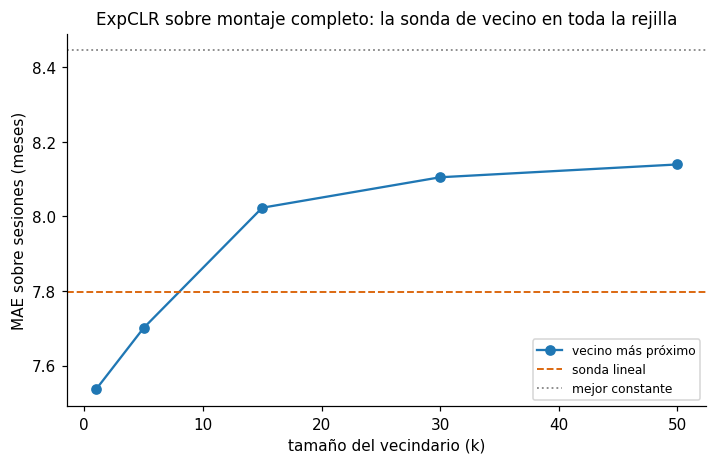

 k   mae     r2   rho  n_sessions
 1 7.536 -0.028 0.287         274
 5 7.701  0.295 0.404         274
15 8.023  0.268 0.361         274
30 8.105  0.256 0.351         274
50 8.139  0.249 0.354         274

mejor k de la rejilla: 1, con MAE 7.536 meses
sonda lineal: 7.797   |   mejor constante: 8.445

Algún tamaño de vecindario alcanza a la sonda lineal, de manera que la lectura
sobre la vecindad local no se sostiene y queda retirada.


In [21]:
def knn_curve(method, zone, grid=None, layer=LAYER, seed=BASE_SEED, n_folds=N_FOLDS):
    """Runs the out-of-fold neighbour probe once per neighbourhood size.

    Args:
        method (str): Variant name.
        zone (str): Head zone.
        grid (list[int] | None): Neighbourhood sizes to sweep.
        layer (str): Representation to read.
        seed (int): Seed of the fold shuffle.
        n_folds (int): Number of folds.

    Returns:
        pd.DataFrame: One row per k, with the session-level MAE and R2.
    """
    grid = list(K_GRID if grid is None else grid)
    cached = os.path.join(CACHE, f"curva_k_{method}_{zone}_{layer}.csv")
    if os.path.exists(cached):
        return pd.read_csv(cached)

    X, meta = load_zone(zone)
    subjects, y = meta["subject"].to_numpy(), meta["age"].to_numpy(float)
    per_k = {k: [] for k in grid}
    for fold_idx, held_out in enumerate(
            canonical_subject_folds(sorted(np.unique(subjects)), n_folds, seed)):
        encoder = fold_encoder(method, zone, f"fold{fold_idx}", X.shape[1], X.shape[2])
        Z = extract_embeddings(
            encoder, apply_fold_normalisation(X, subjects, held_out, verbose=False),
            DEVICE, representation=layer)
        test = np.isin(subjects, held_out)
        scaler = StandardScaler().fit(Z[~test])
        for k in grid:
            probe = KNeighborsRegressor(n_neighbors=min(k, int((~test).sum())))
            probe.fit(scaler.transform(Z[~test]), y[~test])
            per_k[k].append(aggregate_to_sessions(
                meta[test], y[test], probe.predict(scaler.transform(Z[test]))))

    rows = []
    for k, folds in per_k.items():
        sessions = pd.concat(folds, ignore_index=True)
        rows.append({"k": k, **session_metrics(sessions)})
    frame = pd.DataFrame(rows)
    frame.to_csv(cached, index=False)
    return frame


CURVE = knn_curve(*ILLUSTRATED)
linear_mae = session_metrics(RESULTS[ILLUSTRATED]["sessions"])["mae"]

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(CURVE.k, CURVE.mae, marker="o", color="#1f77b4", label="vecino más próximo")
ax.axhline(linear_mae, ls="--", lw=1.2, color="#d95f02", label="sonda lineal")
ax.axhline(constant, ls=":", lw=1.2, color="#888888", label="mejor constante")
ax.set_xlabel("tamaño del vecindario (k)"), ax.set_ylabel("MAE sobre sesiones (meses)")
ax.set_title(f"{ILLUSTRATED[0]} sobre {ZONE_LABEL[ILLUSTRATED[1]]}: la sonda de vecino "
             f"en toda la rejilla", fontsize=11)
ax.legend(fontsize=8)
fig.savefig(os.path.join(OUT, "curva_k.png"))
plt.show()

CURVE.to_csv(os.path.join(OUT, "curva_k.csv"), index=False)
print(CURVE.round(3).to_string(index=False))
mejor = CURVE.loc[CURVE.mae.idxmin()]
print(f"\nmejor k de la rejilla: {int(mejor.k)}, con MAE {mejor.mae:.3f} meses")
print(f"sonda lineal: {linear_mae:.3f}   |   mejor constante: {constant:.3f}")
if mejor.mae > linear_mae:
    print("\nNingún tamaño de vecindario alcanza a la sonda lineal, así que la información")
    print("del espacio no se recupera desde la vecindad local, que es lo que el objetivo")
    print("contrastivo optimiza.")
else:
    print("\nAlgún tamaño de vecindario alcanza a la sonda lineal, de manera que la lectura")
    print("sobre la vecindad local no se sostiene y queda retirada.")

## 10. El corte: qué combinaciones pasan, y por qué

Hasta este punto el cuaderno ha mirado las once combinaciones a la vez, y a partir de aquí
pasa a mirar unas pocas, por lo que esta sección recoge el criterio con el que se eligen,
escrito antes de aplicarlo.

El corte se organiza en dos ramas porque las preguntas que se le hacen al espacio latente son
dos, sin que nada garantice que la ganadora de una lo sea también de la otra. La rama
predictiva pregunta qué combinación estima mejor la edad y se resuelve con el error absoluto
medio de la sección 9. La rama estructural pregunta si las ventanas de una visita se agrupan
en una región del espacio, cosa que la rejilla de la sección 5 sugiere con un brazo dominado
por los 36 meses en algunas celdas, aunque la silueta por edad de sus títulos no llega a
recogerlo porque promedia las cuatro visitas y cancela la estructura de una sola.

Para medir esa concentración se colapsa cada sesión a su centroide, se buscan sus diez vecinos
más próximos en las 128 dimensiones entre sesiones de otros niños y se calcula qué fracción de
esos vecinos pertenece también a la visita de 36 meses. La referencia con la que se compara es
la media de la distribución nula, obtenida por permutación, y sobre ella se informa el exceso
normalizado, que vale cero en el azar y uno en la concentración perfecta.

Tres decisiones sostienen ese cálculo. La primera toma la sesión como unidad y no la ventana,
ya que las 851 ventanas de 36 meses proceden de 60 sesiones de 34 niños y su número efectivo
es 31, con lo cual tratarlas como intercambiables multiplicaría por cinco la precisión
aparente; a esto se añade que las sesiones de 36 meses son más largas que la media, 14,2
ventanas por 9,5, y cualquier promedio sin ponderar premiaría a esa visita por su duración.
La segunda excluye al propio niño del vecindario, ya que sin esa exclusión una región formada
por dos niños puntuaría como concentrada porque sus propios puntos se avalan entre sí. La
tercera mide las once combinaciones en los diez codificadores y no solo en el que dibuja, ya
que cada pliegue da un espacio coherente y el mosaico concatenado mezcla diez sistemas de
coordenadas, de lo que se informan la media y la dispersión entre pliegues; cada uno de esos
espacios es de dentro de pliegue para el noventa por ciento de los niños, por lo que el número
describe una geometría y no estima rendimiento fuera de muestra.

Junto a las once se miden tres referencias fijas, la señal cruda, una reducción por
componentes principales a 128 dimensiones y un codificador sin entrenar. Sin ellas el número
carece de escala, ya que casi cualquier espacio supera al azar, y con ellas la pregunta pasa a
ser cuánta de la estructura que ya estaba en la señal sobrevive al paso por el codificador.

In [22]:
def concentration_across_folds(method, zone, folds=CONCENTRATION_FOLDS):
    """Averages the concentration of one combination over its ten encoders.

    Args:
        method (str): Variant name.
        zone (str): Head zone.
        folds (list[int]): Folds whose encoder is used.

    Returns:
        dict | None: Averaged measures, or None if the encoders are missing.
    """
    rows = []
    for fold_idx in folds:
        try:
            Z, meta = single_fold_space(method, zone, fold_idx=fold_idx)
        except FileNotFoundError as error:
            # Un pliegue que falta cambia el número que se promedia, y la excepción también
            # cubre el caso de varios checkpoints indistinguibles, que es una salvaguarda
            # deliberada. Se dice en voz alta; la columna pliegues deja el rastro.
            print(f"    [aviso] {method}/{zone} pliegue {fold_idx} omitido: {error}", flush=True)
            continue
        rows.append(concentration_of(Z, meta, n_perm=N_PERMUTATIONS))
    if not rows:
        return None
    frame = pd.DataFrame(rows)
    # No p-value is combined across folds. The median of ten p-values is not a p-value: it is
    # not uniform under the null and controls nothing, and the ten folds share ninety per cent
    # of the children, so Fisher and Stouffer do not apply either. What the folds give is a
    # spread, and that is what is reported. The inference that matters is the paired contrast
    # against the references, which is computed below.
    return {"pureza": frame.pureza.mean(), "pureza_de": frame.pureza.std(ddof=1),
            "azar": frame.azar.mean(), "exceso": frame.exceso.mean(),
            "pureza_ventana": frame.pureza_ventana.mean(),
            "z_min": frame.z_permutacion.min(), "z_max": frame.z_permutacion.max(),
            "pliegues": len(frame)}


rows = []
for method, zone in COMBINATIONS:
    started = time.time()
    measured = concentration_across_folds(method, zone)
    if measured is None:
        continue
    rows.append({"espacio": f"{method} / {ZONE_LABEL[zone]}", "metodo": method,
                 "zona": zone, "tipo": "aprendido", **measured})
    print(f"  {method:14s} {zone:10s} {time.time() - started:6.1f} s", flush=True)

# The references do not depend on any encoder, so they are measured once on the reference
# metadata. Without them the numbers above have no scale.
for label, Z in [("señal cruda", raw_space("all", "raw")),
                 ("PCA de 128 componentes", raw_space("all", "pca")),
                 ("codificador sin entrenar", untrained_space("all"))]:
    measured = concentration_of(Z, meta_all, n_perm=N_PERMUTATIONS)
    rows.append({"espacio": label, "metodo": label, "zona": "all", "tipo": "referencia",
                 "pureza_de": np.nan, "pliegues": 1, **measured})

CONCENTRATION = pd.DataFrame(rows).sort_values("exceso", ascending=False)
CONCENTRATION.to_csv(os.path.join(OUT, "concentracion_36m.csv"), index=False)

print(f"\nConcentración de la visita de 36 meses, azar {CONCENTRATION.azar.mean():.3f}\n")
print(CONCENTRATION[["espacio", "tipo", "pureza", "pureza_de", "exceso", "pureza_ventana",
                     "z_min", "z_max", "pliegues"]].round(4).to_string(index=False))
print("\nLa tabla no incluye p-valor. Contra el azar resultan significativos todos los")
print("espacios, incluido el codificador sin entrenar, por lo que ese contraste no ordena")
print("nada. La comparación informativa es el tamaño del exceso respecto de las referencias.")

  ExpCLR         all           2.9 s


  ExpCLR-full    all           2.9 s


  ExpCLR-aper    all           3.0 s


  ExpCLR         frontal       2.2 s


  ExpCLR-full    frontal       2.0 s


...

  ExpCLR         parietal      1.8 s


  ExpCLR-full    parietal      1.8 s


  ExpCLR         occipital     1.7 s


  ExpCLR-full    occipital     1.7 s



Concentración de la visita de 36 meses, azar 0.218

                       espacio       tipo  pureza  pureza_de  exceso  pureza_ventana  z_min   z_max  pliegues
     ExpCLR / montaje completo  aprendido  0.6345     0.1158  0.5339          0.3858 5.6912 19.4776        10
             ExpCLR / parietal  aprendido  0.5572     0.0699  0.4363          0.3179 6.4480 15.1727        10
ExpCLR-full / montaje completo  aprendido  0.5345     0.0483  0.4019          0.2826 5.7232 12.0756        10
              ExpCLR / frontal  aprendido  0.4967     0.0328  0.3533          0.2230 5.6578  7.8780        10
        ExpCLR-full / parietal  aprendido  0.4903     0.0395  0.3502          0.2917 4.8391  9.9021        10
              ExpCLR / central  aprendido  0.4703     0.0619  0.3227          0.2694 4.7281 10.9634        10
         ExpCLR-full / central  aprendido  0.4667     0.0320  0.3203          0.2700 5.7164  8.0216        10
ExpCLR-aper / montaje completo  aprendido  0.4600     0.0383  0.309

In [23]:
# The diagnostic that justifies normalising the centroids. It is reported, not hidden, because
# without it the table above looks like a different result: before the repair the raw signal
# led with 0.602 and the trained encoder trailed at 0.492.
rows = []
for label, Z in [("señal cruda", raw_space("all", "raw")),
                 ("PCA de 128 componentes", raw_space("all", "pca")),
                 ("codificador sin entrenar", untrained_space("all")),
                 (f"{ILLUSTRATED[0]} / {ZONE_LABEL[ILLUSTRATED[1]]}",
                  SPACES[ILLUSTRATED][0])]:
    plain, sessions = session_centroids(Z, meta_all, normalise=False)
    rho, _ = spearmanr(np.linalg.norm(plain, axis=1), sessions.n_windows)
    rows.append({"espacio": label, "rho_norma_ventanas": float(rho)})

ARTEFACT = pd.DataFrame(rows)
ARTEFACT.to_csv(os.path.join(OUT, "artefacto_centroide.csv"), index=False)
longer = sessions.groupby(sessions.age == CONCENTRATION_AGE).n_windows.mean()
print("Correlación entre la norma del centroide de una sesión y cuántas ventanas se promedian\n")
print(ARTEFACT.round(3).to_string(index=False))
print(f"\nventanas por sesión: {CONCENTRATION_AGE} meses {longer[True]:.1f}, resto "
      f"{longer[False]:.1f}")
print("\nEn los espacios de media casi nula la norma del centroide depende casi por completo")
print("del número de ventanas promediadas. Dado que las sesiones de 36 meses son más largas,")
print("sus centroides caen juntos cerca del origen y una medida de vecindad registra esa")
print("proximidad como concentración. Los centroides se proyectan por ello a la esfera unidad")
print("antes de medir, y la medida pasa así a depender de la dirección del centroide.")

Correlación entre la norma del centroide de una sesión y cuántas ventanas se promedian

                  espacio  rho_norma_ventanas
              señal cruda              -0.955
   PCA de 128 componentes              -0.938
 codificador sin entrenar               0.069
ExpCLR / montaje completo              -0.251

ventanas por sesión: 36 meses 14.2, resto 8.2

En los espacios de media casi nula la norma del centroide depende casi por completo
del número de ventanas promediadas. Dado que las sesiones de 36 meses son más largas,
sus centroides caen juntos cerca del origen y una medida de vecindad registra esa
proximidad como concentración. Los centroides se proyectan por ello a la esfera unidad
antes de medir, y la medida pasa así a depender de la dirección del centroide.


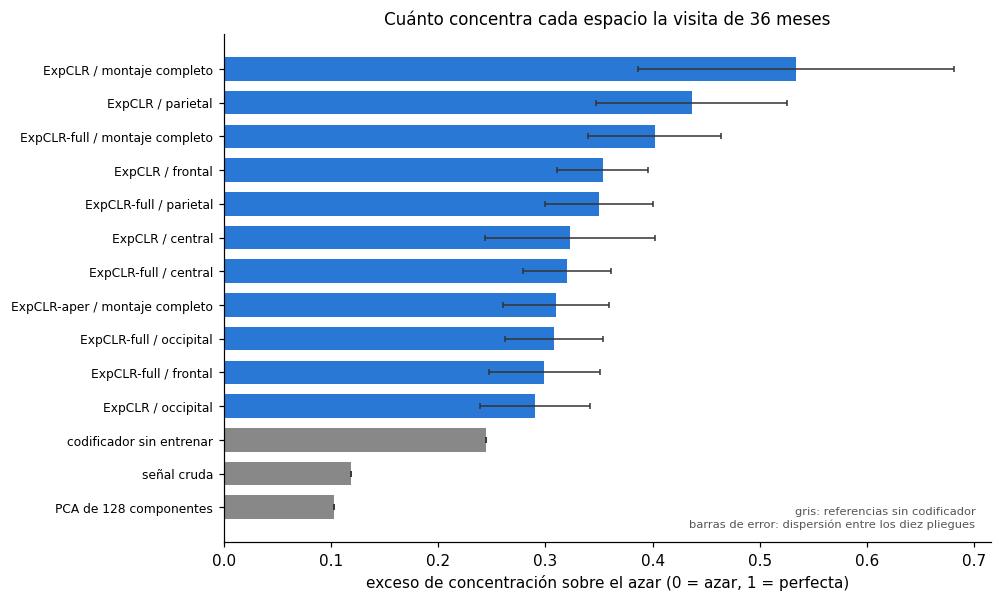


Mejor referencia sin codificador: codificador sin entrenar (exceso 0.245)
Combinaciones aprendidas que la superan: 11 de 11
Ventaja de la mejor aprendida sobre esa referencia: +0.289, frente a una dispersión típica entre pliegues de 0.051


In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
order = CONCENTRATION.sort_values("exceso")
colours = ["#888888" if t == "referencia" else "#2a78d6" for t in order.tipo]
ax.barh(range(len(order)), order.exceso, color=colours, height=0.7)
ax.errorbar(order.exceso, range(len(order)),
            xerr=order.pureza_de.fillna(0) / (1 - order.azar),
            fmt="none", ecolor="#333333", elinewidth=1, capsize=2)
ax.set_yticks(range(len(order)), order.espacio, fontsize=8)
ax.axvline(0, color="#333333", lw=1)
ax.set_xlabel("exceso de concentración sobre el azar (0 = azar, 1 = perfecta)")
ax.set_title("Cuánto concentra cada espacio la visita de 36 meses", fontsize=11)
ax.text(0.98, 0.03, "gris: referencias sin codificador\nbarras de error: dispersión "
        "entre los diez pliegues", transform=ax.transAxes, ha="right", fontsize=7.5,
        color="#555555")
fig.savefig(os.path.join(OUT, "concentracion_36m.png"))
plt.show()

learned = CONCENTRATION[CONCENTRATION.tipo == "aprendido"]
best_reference = CONCENTRATION[CONCENTRATION.tipo == "referencia"].nlargest(1, "exceso").iloc[0]
above = learned[learned.exceso > best_reference.exceso]
margin = learned.exceso.max() - best_reference.exceso
spread = learned.pureza_de.median() / (1 - learned.azar.mean())

# The reading is printed always, not only when it is negative: a figure whose interpretation
# depends on which branch fires leaves the reader without one half of the time.
print(f"\nMejor referencia sin codificador: {best_reference.espacio} "
      f"(exceso {best_reference.exceso:.3f})")
print(f"Combinaciones aprendidas que la superan: {len(above)} de {len(learned)}")
print(f"Ventaja de la mejor aprendida sobre esa referencia: {margin:+.3f}, frente a una "
      f"dispersión típica entre pliegues de {spread:.3f}")
if margin < spread:
    print("La ventaja cabe dentro de la dispersión entre pliegues, así que no es distinguible.")

### 10.1. El control: ¿es una región de edad o son tres niños?

El espacio agrupa algo por niño, lo que obliga a considerar la sospecha de que el brazo esté
formado por las ventanas de dos o tres críos en su visita de 36 meses, caso en el que no
diría nada sobre maduración.

Tres comprobaciones ordenadas de menor a mayor exigencia responden a esa sospecha. La
exclusión del propio niño está ya dentro de la medida. El recuento de niños de la región se
compara con el que cabría esperar si la región fuese un puñado de grabaciones sueltas,
sorteando sesiones enteras. La permutación dentro de cada niño baraja la etiqueta de edad
entre las visitas de un mismo crío y preserva su identidad, las edades que visitó y cuántas
sesiones de 36 meses tiene, por lo que cualquier concentración que sobreviva a ese barajado
tendrá un origen distinto de la identidad del niño.

La región se delimita sobre la propia medida y no sobre el dibujo, tomando el decil superior
de pureza local dentro de las sesiones de 36 meses, con el fin de que su tamaño sea comparable
entre las once combinaciones.

In [25]:
def concentrated_region(Z, meta, age=CONCENTRATION_AGE, k=K_SESSION, quantile=0.9):
    """Returns the sessions of one visit whose neighbourhood is mostly of that visit.

    Args:
        Z (np.ndarray): Representation of every window.
        meta (pd.DataFrame): Window metadata.
        age (int): Visit of interest.
        k (int): Neighbours considered.
        quantile (float): Quantile of local purity above which a session is in the region.

    Returns:
        pd.DataFrame: The sessions of the visit with their local purity and a region flag.
    """
    centroids, sessions = session_centroids(Z, meta)
    is_target = (sessions.age == age).to_numpy()
    neighbours = alien_neighbours(centroids, sessions.subject.to_numpy(), k)
    local = is_target[neighbours].mean(axis=1)
    target = sessions.assign(pureza_local=local)[is_target]
    # Un cuantil y no un umbral absoluto: con un corte fijo en 0,5 la region llegaba a cubrir
    # tres cuartas partes de la clase, y una region que es casi toda la clase no es una region.
    # El decil superior tiene el mismo tamano en las once combinaciones, que es lo que las hace
    # comparables y lo que da al nulo agrupado algo que pueda rechazar.
    return target.assign(region=target.pureza_local >= target.pureza_local.quantile(quantile))


def effective_count(counts):
    """Effective number of contributors, which discounts a dominated distribution.

    Twenty-four children of whom three supply most of the sessions should not score as
    twenty-four. This is the inverse Herfindahl index of the shares.

    Args:
        counts (np.ndarray): Sessions contributed by each child.

    Returns:
        float: Effective number of children.
    """
    shares = np.asarray(counts, float) / np.sum(counts)
    return float(1.0 / np.sum(shares ** 2))


def clustered_null(sessions, size, n_draws=2000, seed=BASE_SEED):
    """Children expected in a region of a given size if it were a handful of recordings.

    Sampling whole sessions, never windows: windows of one session are not interchangeable,
    so a window-level null would be an unreachable ceiling rather than a reference.

    Args:
        sessions (pd.DataFrame): Sessions of the visit, one row each.
        size (int): Sessions in the observed region.
        n_draws (int): Replicates.
        seed (int): Seed.

    Returns:
        tuple: (mean, 2.5th and 97.5th percentiles of the child count).
    """
    rng = np.random.default_rng(seed)
    subjects = sessions.subject.to_numpy()
    counts = [len(np.unique(rng.choice(subjects, size=size, replace=False)))
              for _ in range(n_draws)]
    return float(np.mean(counts)), float(np.percentile(counts, 2.5)), \
        float(np.percentile(counts, 97.5))


rows = []
for method, zone in COMBINATIONS:
    Z, meta = single_fold_space(method, zone, fold_idx=DRAW_FOLD)
    region = concentrated_region(Z, meta)
    inside = region[region.region]
    if not len(inside):
        continue
    per_child = inside.groupby("subject").size()
    expected, low, high = clustered_null(region, len(inside))
    rows.append({"espacio": f"{method} / {ZONE_LABEL[zone]}", "metodo": method, "zona": zone,
                 "sesiones_region": len(inside), "ninos_region": inside.subject.nunique(),
                 "ninos_efectivos": effective_count(per_child.to_numpy()),
                 "ninos_esperados": expected, "esperado_bajo": low, "esperado_alto": high,
                 "cobertura": inside.subject.nunique() / region.subject.nunique()})

REGION = pd.DataFrame(rows).sort_values("ninos_region", ascending=False)
REGION["huella_de_sujeto"] = REGION.ninos_region < REGION.esperado_bajo
REGION.to_csv(os.path.join(OUT, "region_36m.csv"), index=False)
print("Quién forma la región concentrada de 36 meses, en el codificador que dibuja\n")
print(REGION.round(2).to_string(index=False))
print(f"\nCombinaciones cuya región es compatible con huella de sujeto: "
      f"{int(REGION.huella_de_sujeto.sum())} de {len(REGION)}")

Quién forma la región concentrada de 36 meses, en el codificador que dibuja

                       espacio      metodo      zona  sesiones_region  ninos_region  ninos_efectivos  ninos_esperados  esperado_bajo  esperado_alto  cobertura  huella_de_sujeto
              ExpCLR / frontal      ExpCLR   frontal               16            15            14.22            14.13           12.0           16.0       0.44             False
         ExpCLR-full / frontal ExpCLR-full   frontal               13            12            11.27            11.75           10.0           13.0       0.35             False
       ExpCLR-full / occipital ExpCLR-full occipital               11            10             9.31            10.12            8.0           11.0       0.29             False
ExpCLR-full / montaje completo ExpCLR-full       all               10             8             7.14             9.28            8.0           10.0       0.24             False
              ExpCLR / central      Ex

In [26]:
# The finalists of each branch, chosen by the criterion each branch declared, and never by
# what the drawing suggests.
PREDICTIVE = [k for k in sorted(RESULTS,
                                key=lambda k: session_metrics(RESULTS[k]["sessions"])["mae"])][:2]
concentration_rank = CONCENTRATION[CONCENTRATION.tipo == "aprendido"]
STRUCTURAL = [(r.metodo, r.zona) for r in concentration_rank.head(2).itertuples()]
FINALISTS = {"predictiva": PREDICTIVE, "estructural": STRUCTURAL}

# The branches can pick the same combinations, and with these data they do. Every later
# section iterates over the unique spaces, never over the branches: counting a space twice
# would draw the same panel twice and, worse, enter the same contrast twice into a family of
# multiple comparisons, which invalidates the correction.
FINALIST_SPACES = list(dict.fromkeys(PREDICTIVE + STRUCTURAL))
BRANCH_OF = {pair: " y ".join(name for name, pairs in FINALISTS.items() if pair in pairs)
             for pair in FINALIST_SPACES}
BRANCHES_AGREE = set(PREDICTIVE) == set(STRUCTURAL)

rows = []
for method, zone in FINALIST_SPACES:
    mae = session_metrics(RESULTS[(method, zone)]["sessions"])["mae"]
    match = concentration_rank[(concentration_rank.metodo == method)
                               & (concentration_rank.zona == zone)]
    rows.append({"rama": BRANCH_OF[(method, zone)], "metodo": method,
                 "zona": ZONE_LABEL[zone], "mae_edad": mae,
                 "exceso_concentracion": float(match.exceso.iloc[0]) if len(match) else np.nan})
FINALISTS_TABLE = pd.DataFrame(rows)
FINALISTS_TABLE.to_csv(os.path.join(OUT, "finalistas.csv"), index=False)

print("Las finalistas, con su valor en los dos criterios\n")
print(FINALISTS_TABLE.round(4).to_string(index=False))
if BRANCHES_AGREE:
    print("\nLas dos ramas eligen las mismas combinaciones, que es el resultado del corte:")
    print("la que mejor predice la edad concentra también la visita de 36 meses")
    print("por encima del resto. Queda por tanto una sola lista de finalistas, y las secciones")
    print("que iban a contrastar las dos ramas dibujan y miden una sola vez.")

identity_mae = float(TRIVIAL.set_index("referencia").mae["predictor de identidad"])
mean_mae = float(TRIVIAL.set_index("referencia").mae["constante (media global)"])
median_mae = float(TRIVIAL.set_index("referencia").mae["constante (mediana global)"])
print(f"\nreferencias sin EEG para el MAE: identidad {identity_mae:.3f} | "
      f"constante-media {mean_mae:.3f} | constante-mediana {median_mae:.3f}")
print(f"La frontera que importa es la mediana ({median_mae:.3f}), porque es la constante que "
      f"minimiza el MAE.")
print("\nLas finalistas se eligieron con las mismas 274 sesiones sobre las que se analiza")
print("después el cociente intelectual. Es selección posterior a los datos: la ventaja de la")
print("ganadora incluye ruido, y las once no son distinguibles entre sí dentro de su")
print("incertidumbre. Todo lo que sigue es exploratorio, no confirmatorio.")

# From here on, BEST is the head of the predictive branch and STRUCT the head of the
# structural one. Both names are defined here and nowhere earlier, which is the point of
# the section: no part of the notebook narrows the field before this line.
BEST, STRUCT = PREDICTIVE[0], STRUCTURAL[0]
Z_best, meta_best = SPACES[BEST]
labels_best = latent_map.fit_clusters(Z_best, N_CLUSTERS).labels_
Z_struct, meta_struct = SPACES[STRUCT]
print(f"\nrama predictiva  -> {BEST[0]} sobre {ZONE_LABEL[BEST[1]]}")
print(f"rama estructural -> {STRUCT[0]} sobre {ZONE_LABEL[STRUCT[1]]}")

Las finalistas, con su valor en los dos criterios

                    rama metodo             zona  mae_edad  exceso_concentracion
predictiva y estructural ExpCLR montaje completo    7.7967                0.5339
predictiva y estructural ExpCLR         parietal    8.3721                0.4363

Las dos ramas eligen las mismas combinaciones, que es el resultado del corte:
la que mejor predice la edad concentra también la visita de 36 meses
por encima del resto. Queda por tanto una sola lista de finalistas, y las secciones
que iban a contrastar las dos ramas dibujan y miden una sola vez.

referencias sin EEG para el MAE: identidad 8.735 | constante-media 9.076 | constante-mediana 8.445
La frontera que importa es la mediana (8.445), porque es la constante que minimiza el MAE.

Las finalistas se eligieron con las mismas 274 sesiones sobre las que se analiza
después el cociente intelectual. Es selección posterior a los datos: la ventaja de la
ganadora incluye ruido, y las once no son disting

## 11. El espacio dentro de cada visita, y el cociente intelectual

Con una fila por combinación finalista y una columna por visita, la figura colorea las
ventanas por banda de cociente intelectual en lugar del grupo que encuentra
k-medias, que no corresponde a ninguna categoría que este cuaderno pueda nombrar. Las bandas
son las que define la propia escala Wechsler, con el fin de que la figura se lea contra normas
publicadas y no contra cortes elegidos para esta muestra, y los niños sin medida quedan en
gris, dibujados debajo del resto.

Un corte que hubiera dejado finalistas distintas en cada rama permitiría comparar aquí si la
combinación que concentra la visita de 36 meses ordena el cociente mejor que la que predice la
edad. Con estos datos las dos ramas coinciden, por lo que queda una sola fila y esa comparación
no llega a plantearse.

El pie de la figura recoge tres precisiones necesarias para leerla. El cociente no cambia entre
las visitas de un niño, con lo cual todas sus ventanas llevan el mismo color y colorear por
banda equivale a colorear por niño agrupado; dado que el espacio codifica algo de identidad,
una mancha de un solo color puede corresponder a un único niño. La medida se toma a los 36
meses, por lo que en las visitas de 6, 9 y 16 la banda procede de una puntuación posterior y la
figura pregunta entonces si el EEG temprano anticipa el cociente futuro. El cuaderno ya ha
medido además que el cociente no está en el latente, ya que la sonda de la sección 12 da R2
negativo en las once combinaciones y el contraste de los clústeres contra el cociente no
sobrevive la corrección múltiple, con lo que lo esperable en estos paneles es una nube sin
patrón que replique la limitación declarada por el trabajo previo sobre estos mismos datos.

El codificador es el mismo para las cuatro visitas y solo cambia el filtrado, por lo que
ninguna diferencia entre paneles procede de un entrenamiento distinto. Cada panel es en cambio
una proyección independiente, ya que t-SNE se ejecuta por separado sobre las ventanas de cada
visita y sobre nubes de tamaño distinto, así que las posiciones solo son comparables dentro de
un mismo panel.

In [27]:
scores = subject_target(meta_best, IQ_TARGET)
bands = scores.map(wechsler_band)
band_names = [name for _, name in WECHSLER_BANDS]
counts = bands.value_counts().reindex(band_names, fill_value=0)

BANDS = pd.DataFrame({"banda": band_names, "ninos": counts.values,
                      "cociente_minimo": [scores[bands == b].min() if counts[b] else np.nan
                                          for b in band_names],
                      "cociente_maximo": [scores[bands == b].max() if counts[b] else np.nan
                                          for b in band_names]})
BANDS.to_csv(os.path.join(OUT, "bandas_cociente.csv"), index=False)
print(f"{len(scores)} de {meta_best.subject.nunique()} niños tienen {IQ_TARGET}, "
      f"lo que cubre {int(meta_best.subject.isin(scores.index).sum())} de "
      f"{len(meta_best)} ventanas\n")
print(BANDS.to_string(index=False))

39 de 45 niños tienen cit_36mo, lo que cubre 2441 de 2609 ventanas

                        banda  ninos  cociente_minimo  cociente_maximo
hasta 69, extremadamente bajo      1             69.0             69.0
             70-79, limítrofe      6             72.0             79.0
         80-89, bajo promedio      6             85.0             89.0
             90-109, promedio     12             94.0            109.0
       110-119, alto promedio      9            110.0            118.0
          120 o más, superior      5            120.0            129.0


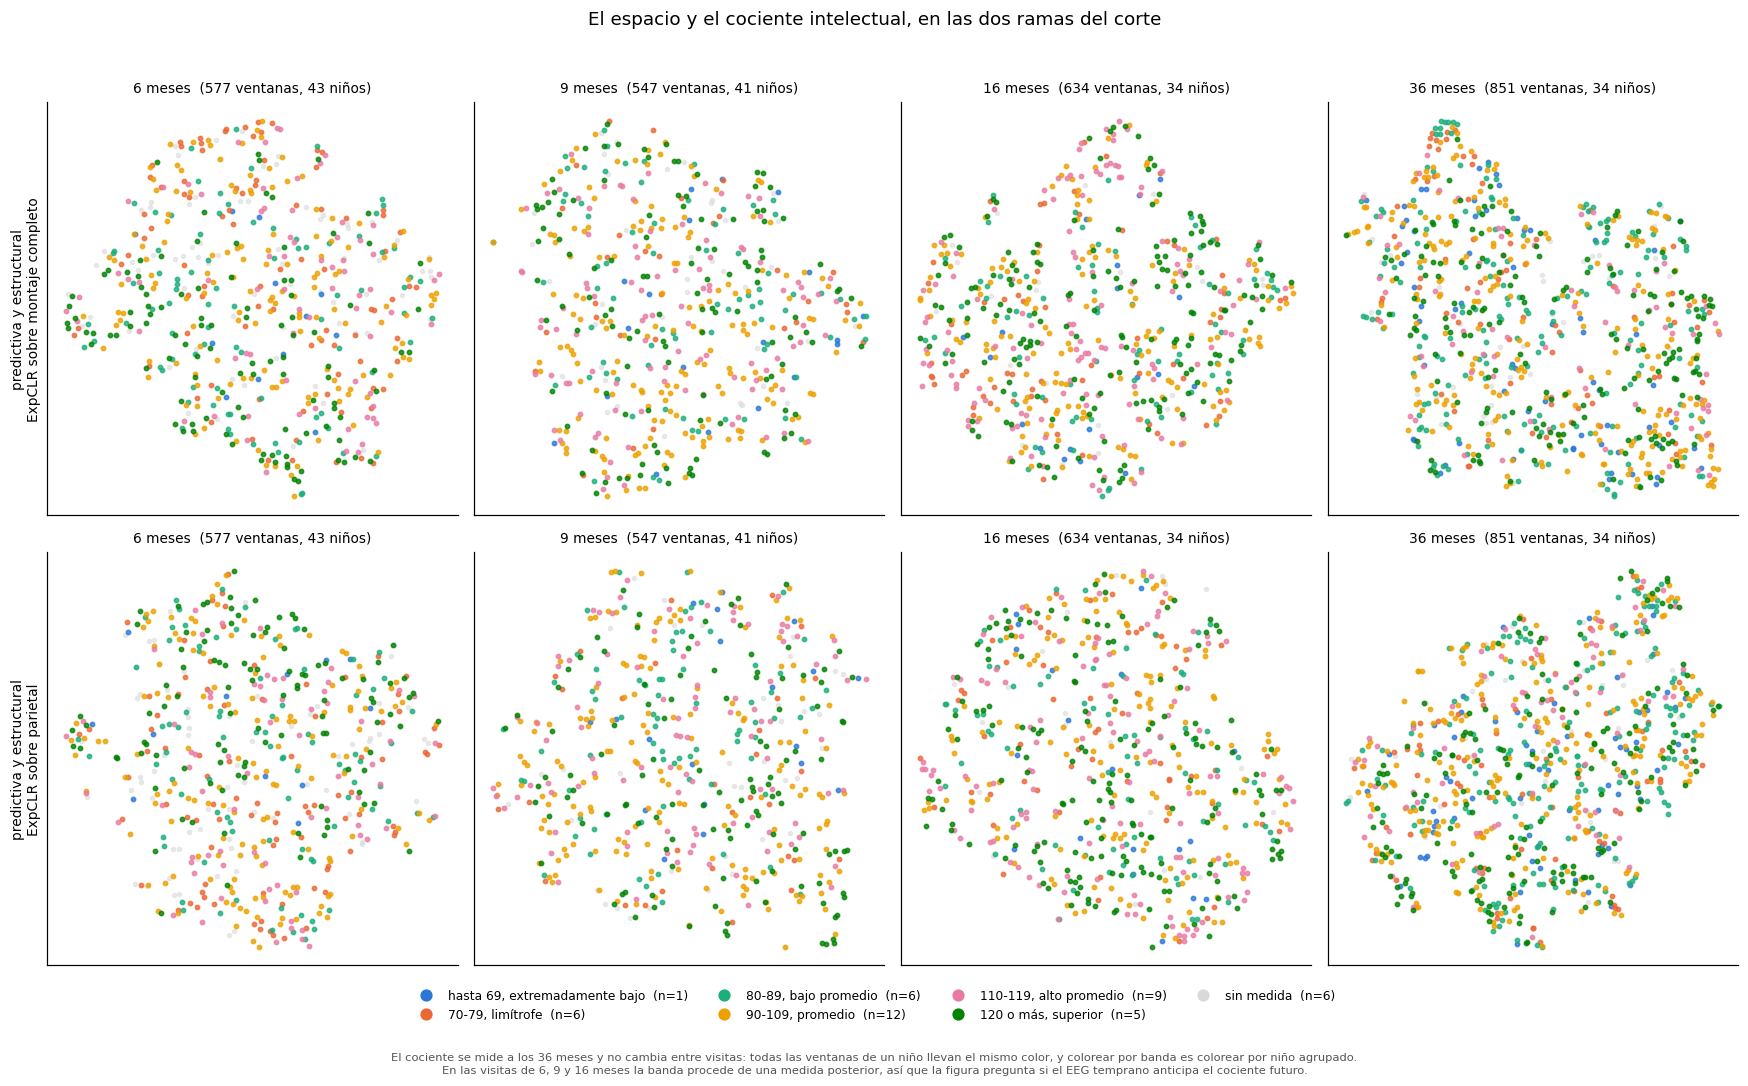

Niños cuyas ventanas llevan más de un color: 0 (debe ser cero: el cociente es una propiedad del niño, no de la ventana)


In [28]:
colour_of_band = dict(zip(band_names, IQ_COLOURS))
# Una fila por espacio, no por rama: si las dos ramas coinciden, dibujar dos veces el mismo
# espacio no compara nada y hace creer al lector que sí.
BRANCHES = [(BRANCH_OF[pair], pair) + SPACES[pair] for pair in FINALIST_SPACES]

fig, axes = plt.subplots(len(BRANCHES), len(AGES), figsize=(16, 4.6 * len(BRANCHES)))
axes = np.atleast_2d(axes)
for row, (branch, pair, Z, meta) in enumerate(BRANCHES):
    band_of_window = meta["subject"].map(bands)
    for col, age in enumerate(AGES):
        ax = axes[row, col]
        mask = (meta["age"] == age).to_numpy()
        coords_age = projection_of(f"{pair[0]}_{pair[1]}_age{age}", Z[mask])
        band_age = band_of_window[mask].to_numpy()

        # The children with no measure go first, underneath, so they never hide the rest.
        missing = pd.isna(band_age)
        ax.scatter(coords_age[missing, 0], coords_age[missing, 1], s=7, alpha=0.55,
                   color=NO_DATA_COLOUR, zorder=1)
        for name in band_names:
            sel = band_age == name
            if sel.sum():
                ax.scatter(coords_age[sel, 0], coords_age[sel, 1], s=8, alpha=0.8,
                           color=colour_of_band[name], zorder=2)

        ax.set_xticks([]), ax.set_yticks([])
        ax.set_title(f"{age} meses  ({int(mask.sum())} ventanas, "
                     f"{meta[mask].subject.nunique()} niños)", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{branch}\n{pair[0]} sobre {ZONE_LABEL[pair[1]]}", fontsize=9)

handles = [plt.Line2D([], [], marker="o", ls="", markersize=7, color=colour_of_band[b],
                      label=f"{b}  (n={counts[b]})") for b in band_names if counts[b]]
handles.append(plt.Line2D([], [], marker="o", ls="", markersize=7, color=NO_DATA_COLOUR,
                          label=f"sin medida  (n={meta_best.subject.nunique() - len(scores)})"))
fig.legend(handles=handles, fontsize=8, loc="lower center", ncols=4, frameon=False,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle("El espacio y el cociente intelectual, en las dos ramas del corte", fontsize=12)
fig.text(0.5, -0.07, "El cociente se mide a los 36 meses y no cambia entre visitas: todas las "
         "ventanas de un niño llevan el mismo color, y colorear por banda es colorear por niño "
         "agrupado.\nEn las visitas de 6, 9 y 16 meses la banda procede de una medida "
         "posterior, así que la figura pregunta si el EEG temprano anticipa el cociente futuro.",
         ha="center", fontsize=7.5, color="#555555")
fig.tight_layout(rect=(0, 0.02, 1, 0.96))
fig.savefig(os.path.join(OUT, "latente_por_edad.png"))
plt.show()

por_nino = pd.DataFrame({"subject": meta_best["subject"],
                         "banda": meta_best["subject"].map(bands)})
distintas = por_nino.dropna().groupby("subject").banda.nunique()
print(f"Niños cuyas ventanas llevan más de un color: {int((distintas > 1).sum())} "
      "(debe ser cero: el cociente es una propiedad del niño, no de la ventana)")

### 11.1 ¿Se comporta el modelo distinto según el cociente?

Esta subsección aborda el quinto aporte del trabajo, ya que un niño cuyo EEG parezca mayor de
lo que es podría tener un cociente distinto, en cuyo caso la discrepancia entre la edad
predicha y la real serviría como marcador.

Para los números se pasa de las seis bandas a tres grupos, ya que dos de las seis reúnen cinco
niños o menos, y los tres resultantes quedan con 13, 12 y 14 niños.

Antes de examinar la discrepancia se aplica un control que decide si la comparación es limpia.
Si
los niños de cociente bajo abandonaran antes el estudio, la cohorte de 36 meses dejaría de ser
la de 6 meses y cualquier diferencia observada se confundiría con la deserción.

In [29]:
scores_group = scores.map(iq_group)
group_names = [name for _, name in IQ_GROUPS]

coverage = (meta_best.assign(grupo=meta_best.subject.map(scores_group))
            .dropna(subset=["grupo"])
            .groupby(["grupo", "age"], observed=True).subject.nunique()
            .unstack(fill_value=0).reindex(group_names))
visits = meta_best.groupby("subject").age.nunique()
coverage["visitas_media"] = [visits[scores_group[scores_group == g].index].mean()
                             for g in group_names]
coverage["ninos"] = [int((scores_group == g).sum()) for g in group_names]
coverage.to_csv(os.path.join(OUT, "cobertura_por_cociente.csv"))
print("Niños de cada grupo que llegan a cada visita\n")
print(coverage.round(2).to_string())
print("\nSi las visitas completadas son parecidas entre grupos, la deserción no se asocia al")
print("cociente y la comparación de las visitas tardías es limpia.")

Niños de cada grupo que llegan a cada visita

age                  6   9  16  36  visitas_media  ninos
grupo                                                   
bajo, menos de 90   13  12   9  12           3.54     13
promedio, 90 a 109  12  11  10  11           3.67     12
alto, 110 o más     13  13  11   9           3.29     14

Si las visitas completadas son parecidas entre grupos, la deserción no se asocia al
cociente y la comparación de las visitas tardías es limpia.


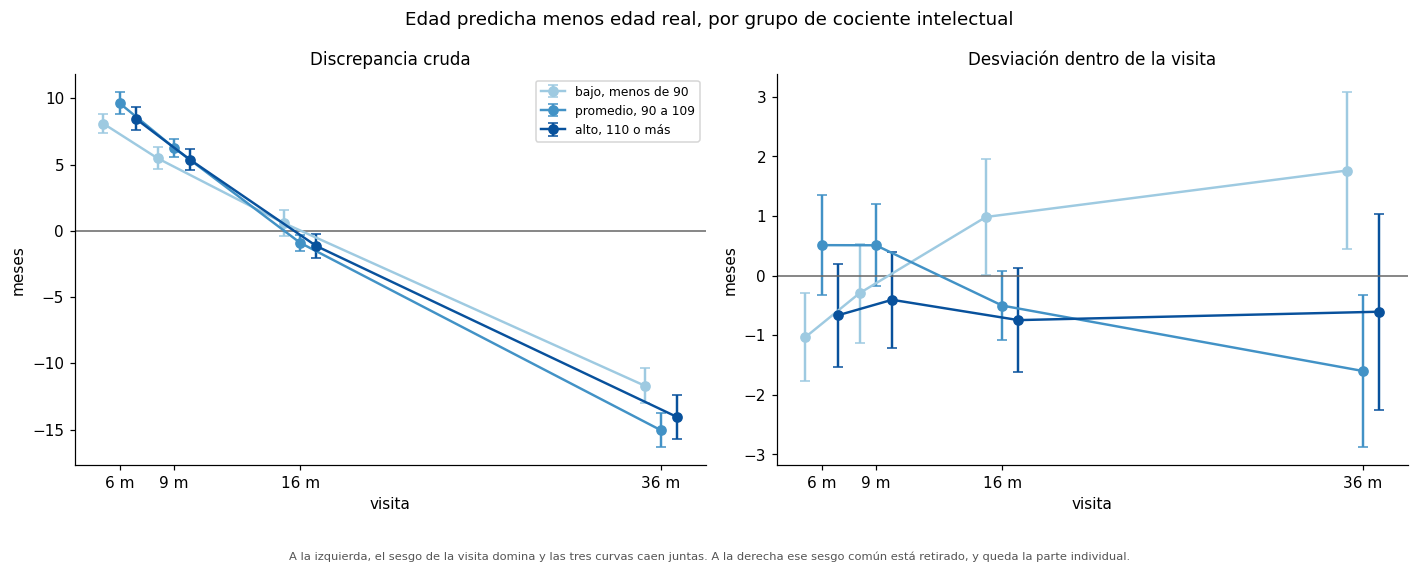

             grupo  age  n_sesiones  ninos  discrepancia  desviacion
   alto, 110 o más    6          26     13         8.446      -0.665
   alto, 110 o más    9          22     13         5.358      -0.405
   alto, 110 o más   16          20     11        -1.154      -0.746
   alto, 110 o más   36          15      9       -14.066      -0.605
 bajo, menos de 90    6          23     13         8.080      -1.030
 bajo, menos de 90    9          18     12         5.471      -0.293
 bajo, menos de 90   16          18      9         0.576       0.984
 bajo, menos de 90   36          23     12       -11.697       1.764
promedio, 90 a 109    6          23     12         9.622       0.512
promedio, 90 a 109    9          21     11         6.273       0.510
promedio, 90 a 109   16          20     10        -0.910      -0.502
promedio, 90 a 109   36          19     11       -15.060      -1.600


In [30]:
sessions_iq = RESULTS[BEST]["sessions"].copy()
sessions_iq["grupo"] = sessions_iq.subject.map(scores_group)
sessions_iq["discrepancia"] = sessions_iq.y_pred - sessions_iq.y_true
# The bias is shared by every child of a visit (+9 months at 6, -13 at 36): it measures which
# visit the session is, not which child. Centring within the visit removes it and leaves the
# individual part, which is the only one that could be a marker.
sessions_iq["desviacion"] = (sessions_iq.discrepancia
                             - sessions_iq.groupby("age").discrepancia.transform("mean"))
sessions_iq = sessions_iq.dropna(subset=["grupo"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
offsets = {g: (i - 1) * 0.9 for i, g in enumerate(group_names)}
for panel, columna, titulo in [
        (axes[0], "discrepancia", "Discrepancia cruda"),
        (axes[1], "desviacion", "Desviación dentro de la visita")]:
    for grupo in group_names:
        sel = sessions_iq[sessions_iq.grupo == grupo]
        medias = sel.groupby("age")[columna].agg(["mean", "sem", "size"])
        panel.errorbar(medias.index + offsets[grupo], medias["mean"], yerr=medias["sem"],
                       fmt="o-", capsize=3, lw=1.6, color=GROUP_COLOURS[grupo], label=grupo)
    panel.axhline(0, lw=1, color="#666666")
    panel.set_xticks(AGES, [f"{a} m" for a in AGES])
    panel.set_xlabel("visita")
    panel.set_ylabel("meses")
    panel.set_title(titulo, fontsize=11)
axes[0].legend(fontsize=8)
fig.suptitle("Edad predicha menos edad real, por grupo de cociente intelectual", fontsize=12)
fig.text(0.5, -0.06, "A la izquierda, el sesgo de la visita domina y las tres curvas caen "
         "juntas. A la derecha ese sesgo común está retirado, y queda la parte "
         "individual.", ha="center", fontsize=7.5, color="#555555")
fig.tight_layout()
fig.savefig(os.path.join(OUT, "discrepancia_por_cociente.png"))
plt.show()

DISCREPANCY = (sessions_iq.groupby(["grupo", "age"], observed=True)
               .agg(n_sesiones=("desviacion", "size"),
                    ninos=("subject", "nunique"),
                    discrepancia=("discrepancia", "mean"),
                    desviacion=("desviacion", "mean"))
               .round(3).reset_index())
DISCREPANCY.to_csv(os.path.join(OUT, "discrepancia_por_cociente.csv"), index=False)
print(DISCREPANCY.to_string(index=False))

In [31]:
rows, pvalues = [], []
for age in AGES:
    en_visita = sessions_iq[sessions_iq.age == age]
    grupos = [en_visita[en_visita.grupo == g].desviacion.to_numpy() for g in group_names]
    grupos = [g for g in grupos if len(g) >= 3]
    if len(grupos) < 2:
        continue
    stat, p = kruskal(*grupos)
    rows.append({"visita": age, "grupos": len(grupos),
                 "ninos": int(en_visita.subject.nunique()), "H": stat, "p": p})
    pvalues.append(p)

IQ_CONTRAST = pd.DataFrame(rows)
if len(IQ_CONTRAST):
    IQ_CONTRAST["p_ajustada"] = benjamini_hochberg(pvalues)
    IQ_CONTRAST["sobrevive"] = IQ_CONTRAST.p_ajustada < 0.05
IQ_CONTRAST.to_csv(os.path.join(OUT, "discrepancia_contraste.csv"), index=False)
print("¿Difiere la desviación entre los tres grupos, dentro de cada visita?\n")
print(IQ_CONTRAST.round(4).to_string(index=False))
print(f"\nCon {int((scores_group.notna()).sum())} niños repartidos en tres grupos y cuatro")
print("visitas, cada celda tiene tres o cuatro niños. Un resultado nulo aquí es lo esperable")
print("y no autoriza a concluir que no exista relación: la muestra solo tendría potencia para")
print("un efecto grande.")

¿Difiere la desviación entre los tres grupos, dentro de cada visita?

 visita  grupos  ninos      H      p  p_ajustada  sobrevive
      6       3     38 1.9149 0.3839      0.5019      False
      9       3     36 1.3786 0.5019      0.5019      False
     16       3     30 3.7015 0.1571      0.4496      False
     36       3     32 2.9850 0.2248      0.4496      False

Con 39 niños repartidos en tres grupos y cuatro
visitas, cada celda tiene tres o cuatro niños. Un resultado nulo aquí es lo esperable
y no autoriza a concluir que no exista relación: la muestra solo tendría potencia para
un efecto grande.


## 12. El cociente intelectual

Esta sección plantea dos preguntas sobre los mismos espacios y sin reentrenar nada, la de si
el latente porta el cociente y la de si los clústeres se corresponden con algún metadato.

El cociente no cambia entre las visitas de un niño, por lo que la unidad de análisis deja de
ser la sesión y pasa a ser el sujeto, con 39 niños que tienen `cit_36mo` en lugar de las 274
sesiones o los 45 niños del resto del cuaderno. Con esa muestra la potencia para detectar una
correlación de 0,30 ronda 0,45, valor que obliga a leer un resultado nulo como falta de
potencia antes que como ausencia de efecto.

El trabajo previo sobre estos mismos datos declaró como limitación que sus clústeres no
correlaban con el cociente, el nivel socioeconómico ni el temperamento, y esta sección
contrasta esa limitación con el procedimiento descrito.

In [32]:
# IQ_TARGET, WECHSLER_FLOOR and subject_target live in section 3, because section 9 already
# needed them to colour its panels.


def iq_probe(method, zone, target=IQ_TARGET):
    """Regresses the quotient from the latent space, out of fold, at subject level.

    Args:
        method (str): Variant name.
        zone (str): Head zone.
        target (str): Metadata column holding the quotient.

    Returns:
        pd.DataFrame | None: One row per scored child, or None if there is no encoder.
    """
    cached = os.path.join(CACHE, f"iq_{method}_{zone}_{target}.csv")
    if os.path.exists(cached):
        return pd.read_csv(cached, dtype={"subject": str})

    X, meta = load_zone(zone)
    labels = subject_target(meta, target)
    if len(labels) < N_FOLDS:
        return None

    subjects = meta["subject"].to_numpy()
    folds = canonical_subject_folds(sorted(np.unique(subjects)), N_FOLDS, BASE_SEED)
    out = []
    for fold_idx, held_out in enumerate(folds):
        encoder = fold_encoder(method, zone, f"fold{fold_idx}", X.shape[1], X.shape[2])
        Xn = apply_fold_normalisation(X, subjects, held_out, verbose=False)
        Z = extract_embeddings(encoder, Xn, DEVICE, representation=LAYER)

        frame = pd.DataFrame(Z).assign(subject=subjects)
        by_subject = frame.groupby("subject").mean()
        by_subject = by_subject.loc[by_subject.index.intersection(labels.index)]
        y = labels.loc[by_subject.index].to_numpy(float)

        test = np.isin(by_subject.index.to_numpy(), held_out)
        if test.sum() == 0 or (~test).sum() < 2:
            continue
        values = by_subject.to_numpy()
        scaler, probe = fit_probe(values[~test], y[~test],
                                  by_subject.index.to_numpy()[~test])
        out.append(pd.DataFrame({
            "subject": by_subject.index.to_numpy()[test], "y_true": y[test],
            "y_pred": probe.predict(scaler.transform(values[test])), "fold": fold_idx,
        }))
    if not out:
        return None
    predictions = pd.concat(out, ignore_index=True)
    predictions.to_csv(cached, index=False)
    return predictions


labels_iq = subject_target(meta_all, IQ_TARGET)
print(f"{len(labels_iq)} niños con {IQ_TARGET} valido "
      f"(rango {labels_iq.min():.0f} - {labels_iq.max():.0f})\n")

rows = []
for method, zone in COMBINATIONS:
    predictions = iq_probe(method, zone)
    if predictions is None:
        continue
    y, p = predictions.y_true.to_numpy(), predictions.y_pred.to_numpy()
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    rows.append({"metodo": method, "zona": zone, "n": len(predictions),
                 "mae": float(np.mean(np.abs(y - p))),
                 "r2": 1 - float(np.sum((y - p) ** 2)) / ss_tot if ss_tot > 0 else np.nan,
                 "rho": float(pd.Series(y).corr(pd.Series(p), method="spearman"))})
IQ = pd.DataFrame(rows).sort_values("mae")
IQ.loc[len(IQ)] = {"metodo": "constante", "zona": "-", "n": len(labels_iq),
                   "mae": float(np.mean(np.abs(labels_iq - labels_iq.mean()))),
                   "r2": 0.0, "rho": np.nan}
IQ.to_csv(os.path.join(OUT, "cociente_sonda.csv"), index=False)
print(f"Predicción de {IQ_TARGET} desde el latente, a nivel sujeto\n")
print(IQ.round(3).to_string(index=False))

39 niños con cit_36mo valido (rango 69 - 129)

Predicción de cit_36mo desde el latente, a nivel sujeto

     metodo      zona  n    mae     r2    rho
ExpCLR-full       all 39 13.418 -0.015  0.231
ExpCLR-full occipital 39 14.175 -0.043 -0.292
ExpCLR-aper       all 39 14.506 -0.043  0.081
ExpCLR-full   central 39 14.554 -0.030 -0.026
     ExpCLR   frontal 39 14.782 -0.067 -0.183
     ExpCLR       all 39 14.890 -0.093  0.050
     ExpCLR  parietal 39 14.899 -0.096 -0.094
     ExpCLR occipital 39 15.046 -0.141 -0.552
ExpCLR-full  parietal 39 15.512 -0.162 -0.042
ExpCLR-full   frontal 39 15.873 -0.208 -0.113
     ExpCLR   central 39 16.302 -0.420 -0.086
  constante         - 39 14.338  0.000    NaN


### 12.1 Los nueve índices de cognición, sobre las finalistas

A los 36 meses la escala Wechsler aporta cuatro índices
(comprensión verbal, visoespacial, memoria de trabajo y el total) y a los 48 aporta cinco, con
la incorporación del razonamiento fluido, por lo que atender únicamente al total dejaría sin
examinar ocho columnas de la hoja de datos.

La potencia se declara antes de mirar los resultados. La celda calcula para cada índice, y con
su tamaño de muestra real, la correlación de Spearman más pequeña que este estudio podría
detectar a potencia 0,8, y la recoge en la columna `rho_detectable`. Ningún número se escribe
aquí a mano, ya que la muestra de cada índice difiere: el suelo de la escala retira
puntuaciones imposibles y deja entre 31 y 39 niños según la prueba.

Las correlaciones que la literatura de EEG y cognición infantil suele reportar se sitúan entre
0,20 y 0,35, muy por debajo de ese umbral, de manera que un resultado nulo en esta sección
informa antes del tamaño de la muestra que de la relación entre las variables.

Las dos edades se corrigen como familias separadas, ya que corresponden a dos administraciones
distintas de la prueba y no a una sola batería de nueve medidas.

In [33]:
COGNITION = {"icv_36mo": ("comprensión verbal", "36 meses"),
             "ive_36mo": ("visoespacial", "36 meses"),
             "imt_36mo": ("memoria de trabajo", "36 meses"),
             "cit_36mo": ("total", "36 meses"),
             "icv_48mo": ("comprensión verbal", "48 meses"),
             "ive_48mo": ("visoespacial", "48 meses"),
             "irf_48mo": ("razonamiento fluido", "48 meses"),
             "imt_48mo": ("memoria de trabajo", "48 meses"),
             "cit_48mo": ("total", "48 meses")}


def detectable_rho(n, alpha=0.05, power=0.8):
    """Smallest Spearman correlation this sample size can detect.

    Uses the Fisher transform with the Bonett-Wright variance, which is the standard
    approximation for the rank correlation.

    Args:
        n (int): Children with the measure.
        alpha (float): Two-sided significance level.
        power (float): Target power.

    Returns:
        float: The minimum detectable correlation.
    """
    from scipy.stats import norm
    target = norm.ppf(1 - alpha / 2) + norm.ppf(power)
    low, high = 0.0, 0.99
    for _ in range(60):
        mid = (low + high) / 2
        if np.arctanh(mid) / np.sqrt((1 + mid ** 2 / 2) / (n - 3)) < target:
            low = mid
        else:
            high = mid
    return high


rows = []
for method, zone in FINALIST_SPACES:
    for column, (label, wave) in COGNITION.items():
        predictions = iq_probe(method, zone, column)
        if predictions is None or len(predictions) < N_FOLDS:
            print(f"  [aviso] sin sonda para {method}/{zone} sobre {column}")
            continue
        y, p = predictions.y_true.to_numpy(), predictions.y_pred.to_numpy()
        rho, pvalue = spearmanr(y, p)
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        rows.append({"rama": BRANCH_OF[(method, zone)],
                     "espacio": f"{method} / {ZONE_LABEL[zone]}",
                     "indice": label, "edad": wave, "n": len(y),
                     "rho": float(rho), "p": float(pvalue),
                     "r2": 1 - float(np.sum((y - p) ** 2)) / ss_tot if ss_tot else np.nan,
                     "rho_detectable": detectable_rho(len(y))})

COG = pd.DataFrame(rows)
# Two families, one per administration of the scale, corrected separately.
COG["p_ajustada"] = np.nan
for wave in COG.edad.unique():
    sel = COG.edad == wave
    COG.loc[sel, "p_ajustada"] = benjamini_hochberg(COG.loc[sel, "p"].to_numpy())
COG["sobrevive"] = COG.p_ajustada < 0.05
COG.to_csv(os.path.join(OUT, "cognicion_finalistas.csv"), index=False)

print("Correlación entre el índice observado y el predicho desde el latente\n")
print(COG.round(3).to_string(index=False))
print(f"\nContrastes que sobreviven la corrección: {int(COG.sobrevive.sum())} de {len(COG)}")
print(f"correlación máxima observada en valor absoluto: {COG.rho.abs().max():.3f}")
print(f"correlación mínima detectable a potencia 0,8:   "
      f"{COG.rho_detectable.min():.3f} a {COG.rho_detectable.max():.3f}")

Correlación entre el índice observado y el predicho desde el latente

                    rama                   espacio              indice     edad  n    rho     p     r2  rho_detectable  p_ajustada  sobrevive
predictiva y estructural ExpCLR / montaje completo  comprensión verbal 36 meses 39 -0.299 0.065 -0.128           0.455       0.173      False
predictiva y estructural ExpCLR / montaje completo        visoespacial 36 meses 38  0.105 0.530 -0.082           0.461       0.649      False
predictiva y estructural ExpCLR / montaje completo  memoria de trabajo 36 meses 39 -0.172 0.295 -0.067           0.455       0.590      False
predictiva y estructural ExpCLR / montaje completo               total 36 meses 39  0.050 0.763 -0.093           0.455       0.763      False
predictiva y estructural ExpCLR / montaje completo  comprensión verbal 48 meses 36 -0.049 0.774 -0.167           0.473       0.775      False
predictiva y estructural ExpCLR / montaje completo        visoespacial 48 mese

In [34]:
METADATA = {"cit_36mo": "cociente 36 m", "cit_48mo": "cociente 48 m", "ses": "nivel socioec.",
            "ibq_es": "IBQ control", "ibq_na": "IBQ afecto neg.", "cbq_ec": "CBQ control"}


# One value per child, never per window: the metadata is a property of the child, and testing
# it over windows would multiply the sample by fifty without adding a single observation.
frame = meta_best.assign(cluster=labels_best)
subject_cluster = (frame.groupby("subject").cluster
                   .agg(lambda s: s.value_counts().idxmax()))

rows, pvalues = [], []
for column, label in METADATA.items():
    if column not in meta_best.columns:
        continue
    values = subject_target(meta_best, column) if column.startswith("cit") \
        else meta_best.groupby("subject")[column].first().dropna()
    shared = values.index.intersection(subject_cluster.index)
    groups = [values.loc[shared][subject_cluster.loc[shared] == c].to_numpy()
              for c in sorted(subject_cluster.loc[shared].unique())]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2:
        continue
    stat, p = kruskal(*groups)
    rows.append({"metadato": label, "n": len(shared), "grupos": len(groups),
                 "H": stat, "p": p})
    pvalues.append(p)

CLUSTER_META = pd.DataFrame(rows)
if len(CLUSTER_META):
    CLUSTER_META["p_ajustada"] = benjamini_hochberg(pvalues)
    CLUSTER_META["sobrevive"] = CLUSTER_META.p_ajustada < 0.05
CLUSTER_META.to_csv(os.path.join(OUT, "clusteres_metadatos.csv"), index=False)
print(f"Kruskal-Wallis de cada metadato entre los clústeres de {BEST[0]} "
      f"sobre {ZONE_LABEL[BEST[1]]}\n")
print(CLUSTER_META.round(4).to_string(index=False))
print("\nCada niño aporta un valor y no una ventana. Con grupos de entre siete y quince")
print("niños, solo un efecto grande resultaría detectable.")

Kruskal-Wallis de cada metadato entre los clústeres de ExpCLR sobre montaje completo

       metadato  n  grupos      H      p  p_ajustada  sobrevive
  cociente 36 m 39       2 0.1951 0.6587      0.9577      False
  cociente 48 m 36       2 0.0028 0.9577      0.9577      False
 nivel socioec. 36       2 0.0377 0.8460      0.9577      False
    IBQ control 39       2 0.1370 0.7113      0.9577      False
IBQ afecto neg. 39       2 0.9639 0.3262      0.9577      False
    CBQ control 32       2 0.2293 0.6320      0.9577      False

Cada niño aporta un valor y no una ventana. Con grupos de entre siete y quince
niños, solo un efecto grande resultaría detectable.


## 13. Los contrastes, fijados antes de mirar la tabla

Las once combinaciones comparten pliegues y niños, por lo que todas las comparaciones entre
ellas son pareadas, y comprobar si dos intervalos marginales se solapan no equivale a una
prueba.

El contraste primario es uno solo y enfrenta ExpCLR con `P_madurativo` sobre el montaje
completo a la regresión del descriptor sin codificador, ya que en él se concreta la pregunta
del trabajo, la de si el contraste guiado aporta algo por encima de regresar directamente el
descriptor que lo guía.

A ese contraste se añaden dos familias, la primera con el efecto del descriptor sobre el
montaje completo y la segunda con el efecto de la zona utilizando `P_full`. La corrección de
Benjamini-Hochberg se aplica dentro de cada familia y sin cruzarlas, ya que `P_aper` solo
existe sobre el montaje completo y la malla de combinaciones queda por ello incompleta.

In [35]:
# B1 was computed in section 10, because the ladder needed it.
if B1 is None:
    print("El descriptor no está materializado; el contraste primario queda pendiente.")
else:
    primary = paired_bootstrap_difference(reference["sessions"], B1, "mae")
    low, high = bootstrap_ci(B1, "mae")
    print("Contraste primario\n")
    print(f"  ExpCLR P_madurativo, montaje completo : MAE "
          f"{session_metrics(reference['sessions'])['mae']:.3f} meses")
    print(f"  descriptor sin codificador            : MAE "
          f"{session_metrics(B1)['mae']:.3f} meses  IC95 [{low:.3f}, {high:.3f}]")
    print(f"\n  diferencia pareada: {primary['diff']:.3f} meses, "
          f"IC95 [{primary['ci_low']:.3f}, {primary['ci_high']:.3f}], "
          f"{primary['n_paired_sessions']} sesiones")
    signo = "empeora" if primary["diff"] > 0 else "mejora"
    print(f"  lectura: " + ("no hay evidencia de diferencia."
          if primary["ci_low"] <= 0 <= primary["ci_high"] else
          f"el paso contrastivo {signo} el error en {abs(primary['diff']):.3f} meses "
          f"respecto a regresar directamente el descriptor que lo guía."))
    with open(os.path.join(OUT, "contraste_primario.json"), "w") as handle:
        json.dump(primary, handle, indent=2)

Contraste primario

  ExpCLR P_madurativo, montaje completo : MAE 7.797 meses
  descriptor sin codificador            : MAE 3.125 meses  IC95 [2.780, 3.504]

  diferencia pareada: 4.672 meses, IC95 [3.827, 5.472], 274 sesiones
  lectura: el paso contrastivo empeora el error en 4.672 meses respecto a regresar directamente el descriptor que lo guía.


### 13.1 El contraste que decide si hay resultado

El contraste primario compara la representación con el descriptor experto, y falta todavía el
más básico de todos, que la compara con no usar nada, es decir, con la mejor constante.

De la elección de esa constante depende la conclusión. La métrica principal es el error
absoluto medio y la constante que lo minimiza es la mediana, ya que la media de la edad de
sesión está en 15,65 meses por efecto del diseño longitudinal, que la arrastra hacia arriba, y
predecir ese valor produce un error de 9,076 meses mientras predecir la mediana, 9 meses,
produce 8,445. Tomar la media como referencia situaría el listón medio punto por debajo de
donde está y regalaría esa distancia a cualquier combinación.

In [36]:
constant_sessions = reference["sessions"].assign(
    y_pred=float(np.median(reference["sessions"].y_true)))
against_constant = paired_bootstrap_difference(reference["sessions"], constant_sessions, "mae")
CONSTANT_CONTRAST = pd.DataFrame([against_constant])
CONSTANT_CONTRAST.to_csv(os.path.join(OUT, "contraste_constante.csv"), index=False)

print(f"{ILLUSTRATED[0]} sobre {ZONE_LABEL[ILLUSTRATED[1]]} frente a la constante-mediana\n")
print(f"  representación : MAE {session_metrics(reference['sessions'])['mae']:.3f} meses")
print(f"  constante      : MAE {session_metrics(constant_sessions)['mae']:.3f} meses "
      f"(predecir siempre {np.median(reference['sessions'].y_true):.0f} meses)")
print(f"\n  diferencia pareada: {against_constant['diff']:+.3f} meses, "
      f"IC95 [{against_constant['ci_low']:+.3f}, {against_constant['ci_high']:+.3f}]")
if against_constant["ci_low"] <= 0 <= against_constant["ci_high"]:
    print("\n  La representación no llega a distinguirse de predecir la mediana en todos los")
    print("  casos. El resultado condiciona la lectura del resto del cuaderno, ya que las")
    print("  comparaciones posteriores se establecen entre espacios que, tomados como grupo,")
    print("  no han demostrado superar a prescindir del EEG.")
else:
    print("\n  La diferencia excluye el cero.")

ExpCLR sobre montaje completo frente a la constante-mediana

  representación : MAE 7.797 meses
  constante      : MAE 8.445 meses (predecir siempre 9 meses)

  diferencia pareada: -0.649 meses, IC95 [-1.650, +0.322]

  La representación no llega a distinguirse de predecir la mediana en todos los
  casos. El resultado condiciona la lectura del resto del cuaderno, ya que las
  comparaciones posteriores se establecen entre espacios que, tomados como grupo,
  no han demostrado superar a prescindir del EEG.


In [37]:
def paired_pvalue(a, b, metric="mae", n_boot=2000, seed=42):
    """Two-sided bootstrap p-value for the paired difference of a metric.

    Args:
        a (pd.DataFrame): Sessions of one method.
        b (pd.DataFrame): Sessions of the other.
        metric (str): Metric compared.
        n_boot (int): Replicates.
        seed (int): Seed of the resampler.

    Returns:
        float: Two-sided proportion of replicates on the other side of zero.
    """
    keys = [c for c in ("subject", "age", "block") if c in a.columns]
    merged = a.merge(b, on=keys, suffixes=("_a", "_b"))
    rng = np.random.default_rng(seed)
    subjects = merged.subject.unique()
    by_subject = {s: g for s, g in merged.groupby("subject")}

    def difference(sample):
        left = session_metrics(sample.rename(columns={"y_true_a": "y_true",
                                                      "y_pred_a": "y_pred"}))[metric]
        right = session_metrics(sample.rename(columns={"y_true_b": "y_true",
                                                       "y_pred_b": "y_pred"}))[metric]
        return left - right

    diffs = []
    for _ in range(n_boot):
        drawn = rng.choice(subjects, size=len(subjects), replace=True)
        value = difference(pd.concat([by_subject[s] for s in drawn], ignore_index=True))
        if np.isfinite(value):
            diffs.append(value)
    diffs = np.asarray(diffs)
    # Con un numero finito de replicas el p no puede ser cero: su suelo es 1/(n+1). Escribir
    # 0,0 sobrestima la evidencia y ese cero se propaga por Benjamini-Hochberg.
    tail = min(int((diffs <= 0).sum()), int((diffs >= 0).sum()))
    return float(min(1.0, 2 * (tail + 1) / (len(diffs) + 1)))


families = {
    "A: descriptor (montaje completo)":
        [(("ExpCLR-full", "all"), ("ExpCLR", "all")),
         (("ExpCLR-aper", "all"), ("ExpCLR", "all"))],
    "B: zona (P_full)":
        [(("ExpCLR-full", z), ("ExpCLR-full", "all"))
         for z in ("frontal", "central", "parietal", "occipital")],
}

blocks = []
for family, pairs in families.items():
    rows, pvalues = [], []
    for left, right in pairs:
        diff = paired_bootstrap_difference(RESULTS[left]["sessions"],
                                           RESULTS[right]["sessions"], "mae")
        p = paired_pvalue(RESULTS[left]["sessions"], RESULTS[right]["sessions"])
        rows.append({"familia": family,
                     "comparacion": f"{left[0]} {left[1]} - {right[0]} {right[1]}",
                     "diff_mae": diff["diff"], "ic_bajo": diff["ci_low"],
                     "ic_alto": diff["ci_high"], "p": p})
        pvalues.append(p)
    frame = pd.DataFrame(rows)
    frame["p_ajustada"] = benjamini_hochberg(pvalues)
    frame["sobrevive"] = frame.p_ajustada < 0.05
    blocks.append(frame)

SECONDARY = pd.concat(blocks, ignore_index=True)
SECONDARY.to_csv(os.path.join(OUT, "contrastes_secundarios.csv"), index=False)
print("Familias secundarias, Benjamini-Hochberg dentro de cada una\n")
print(SECONDARY.round(4).to_string(index=False))
print("\nUn valor positivo significa más error que la referencia de su familia.")

Familias secundarias, Benjamini-Hochberg dentro de cada una

                         familia                             comparacion  diff_mae  ic_bajo  ic_alto      p  p_ajustada  sobrevive
A: descriptor (montaje completo)            ExpCLR-full all - ExpCLR all    1.9313   1.2780   2.6487 0.0010      0.0010       True
A: descriptor (montaje completo)            ExpCLR-aper all - ExpCLR all    2.4386   1.8395   3.0927 0.0010      0.0010       True
                B: zona (P_full)   ExpCLR-full frontal - ExpCLR-full all    0.8958   0.4761   1.3434 0.0010      0.0040       True
                B: zona (P_full)   ExpCLR-full central - ExpCLR-full all   -0.1693  -0.6206   0.3039 0.4668      0.4668      False
                B: zona (P_full)  ExpCLR-full parietal - ExpCLR-full all   -0.4662  -0.9513   0.0308 0.0710      0.0946      False
                B: zona (P_full) ExpCLR-full occipital - ExpCLR-full all    0.5262   0.1013   0.9684 0.0230      0.0460       True

Un valor positivo sig

## 14. Sonda lineal frente a ajuste fino

Todo lo anterior mide la representación congelada, con el codificador intacto y una regresión
ajustada por encima, lo que informa sobre la utilidad del espacio tal como quedó tras el
preentrenamiento pero deja sin responder qué ocurre cuando se permite que el codificador se
adapte a la tarea.

Esa segunda pregunta ya tiene respuesta, ya que la campaña ejecutó las once combinaciones
también en ajuste fino, con cien épocas y los mismos pliegues. Esta sección lee esos
resultados en lugar de recalcularlos, ya que repetir el entrenamiento costaría diecinueve
horas de cómputo.

La lectura exige una salvedad que altera por completo el significado de las cifras. La campaña
agregó a nivel de sujeto, con lo cual el valor observado de cada niño es la media de sus
visitas ponderada por ventanas, y un niño que acudió a los 6, 9, 16 y 36 meses tiene por
objetivo 23,1 meses, una edad en la que nunca estuvo. La celda siguiente muestra la
consecuencia de esa agregación.

In [38]:
def campaign_predictions(method, zone, eval_mode, campaign="save/expclr/results"):
    """Reads the campaign's per-fold predictions and puts the subject back on them.

    The stored ``subject_avgs`` is a list of pairs with no identifier, but downstream.py
    orders them by sorted subject id within the fold, so the children of the canonical
    partition recover it.

    Args:
        method (str): Variant name, as it appears in the filename.
        zone (str): Head zone.
        eval_mode (str): ``linear_probe`` or ``fine_tuning``.
        campaign (str): Directory holding the per-fold result files.

    Returns:
        pd.DataFrame | None: One row per scored child, or None if the run is missing.

    Raises:
        ValueError: If a fold stores a different number of pairs than children held out.
    """
    _, meta = load_zone(zone)
    folds = canonical_subject_folds(sorted(meta.subject.unique()), N_FOLDS, BASE_SEED)

    rows = []
    for fold_idx, held_out in enumerate(folds):
        path = os.path.join(campaign, f"{method}_{zone}_all_age_fold{fold_idx}.csv")
        if not os.path.exists(path):
            return None
        frame = pd.read_csv(path)
        frame = frame[frame.eval_mode == eval_mode]
        if frame.empty:
            return None
        pairs = [p.split(",") for p in frame.iloc[0].subject_avgs.split(";") if p.strip()]
        subjects = sorted(held_out)
        if len(pairs) != len(subjects):
            raise ValueError(
                f"{path}: {len(pairs)} pares para {len(subjects)} niños retirados.")
        for subject, (y_true, y_pred) in zip(subjects, pairs):
            rows.append({"subject": subject, "y_true": float(y_true),
                         "y_pred": float(y_pred), "fold": fold_idx})
    return pd.DataFrame(rows)


def subject_level_metrics(frame):
    """Returns MAE, R2 and Spearman over one row per child.

    Args:
        frame (pd.DataFrame): Predictions with ``y_true`` and ``y_pred``.

    Returns:
        dict: ``mae``, ``r2``, ``rho`` and ``n``.
    """
    y, p = frame.y_true.to_numpy(float), frame.y_pred.to_numpy(float)
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return {"mae": float(np.mean(np.abs(y - p))),
            "r2": 1 - float(np.sum((y - p) ** 2)) / ss_tot if ss_tot > 0 else np.nan,
            "rho": float(pd.Series(y).corr(pd.Series(p), method="spearman")),
            "n": int(len(frame))}


campaign_linear = campaign_predictions("ExpCLR", "all", "linear_probe")
identity = campaign_linear.assign(y_pred=campaign_linear.y_true)
print("En la unidad de la campaña, el objetivo de cada niño es la media de sus visitas.")
print("El predictor que devuelve exactamente eso, sin mirar el EEG, obtiene:\n")
print(f"  {subject_level_metrics(identity)}")
print("\nEs decir: en esa unidad, acertar es reconocer al niño. Cualquier cifra medida así")
print("premia la identidad, y por eso no puede compararse con el MAE de sesión del cuaderno.")

En la unidad de la campaña, el objetivo de cada niño es la media de sus visitas.
El predictor que devuelve exactamente eso, sin mirar el EEG, obtiene:

  {'mae': 0.0, 'r2': 1.0, 'rho': 0.9999999999999999, 'n': 45}

Es decir: en esa unidad, acertar es reconocer al niño. Cualquier cifra medida así
premia la identidad, y por eso no puede compararse con el MAE de sesión del cuaderno.


In [39]:
rows = []
for method, zone in COMBINATIONS:
    for mode, label in [("linear_probe", "sonda lineal"), ("fine_tuning", "ajuste fino")]:
        frame = campaign_predictions(method, zone, mode)
        if frame is None:
            continue
        rows.append({"metodo": method, "zona": zone, "modo": label,
                     **subject_level_metrics(frame)})
CAMPAIGN = pd.DataFrame(rows)

wide = CAMPAIGN.pivot_table(index=["metodo", "zona"], columns="modo",
                            values=["mae", "r2"]).round(3)
wide.columns = [f"{a}_{b}" for a, b in wide.columns]
wide = wide.reset_index().sort_values("mae_ajuste fino")
CAMPAIGN.to_csv(os.path.join(OUT, "ajuste_fino.csv"), index=False)

print("Las once combinaciones en las dos formas de evaluar, unidad de la campaña\n")
print(wide.to_string(index=False))

reference_constant = campaign_linear.y_true
constant_ft = float(np.mean(np.abs(reference_constant - reference_constant.mean())))
CAMPAIGN_REF = pd.DataFrame([
    {"referencia": "devolver la media de visitas de cada niño", "mae": 0.0, "r2": 1.0},
    {"referencia": "constante (media global del objetivo)", "mae": constant_ft, "r2": 0.0},
])
CAMPAIGN_REF.to_csv(os.path.join(OUT, "ajuste_fino_referencias.csv"), index=False)
print("\nReferencias en esta unidad, sin las cuales la tabla no es interpretable\n")
print(CAMPAIGN_REF.round(3).to_string(index=False))
print(f"\nLa mejor combinación ({wide['mae_ajuste fino'].min():.3f}) queda entre las dos: mejor")
print(f"que la constante ({constant_ft:.3f}) y peor que reconocer al niño (0.000). Cuánto de")
print("esa distancia es maduración y cuánto identidad, esta unidad no lo puede separar.")

Las once combinaciones en las dos formas de evaluar, unidad de la campaña

     metodo      zona  mae_ajuste fino  mae_sonda lineal  r2_ajuste fino  r2_sonda lineal
     ExpCLR       all            1.667             4.220           0.898            0.319
ExpCLR-aper       all            1.804             5.461           0.873           -0.026
ExpCLR-full  parietal            1.979             5.126           0.835            0.040
ExpCLR-full       all            2.109             4.705           0.842            0.143
     ExpCLR   frontal            2.178             5.515           0.835           -0.043
     ExpCLR  parietal            2.518             4.433           0.762            0.227
     ExpCLR   central            2.614             5.007           0.707            0.073
ExpCLR-full   central            2.859             4.975           0.591            0.026
ExpCLR-full   frontal            3.068             5.523           0.644           -0.000
ExpCLR-full occipital    

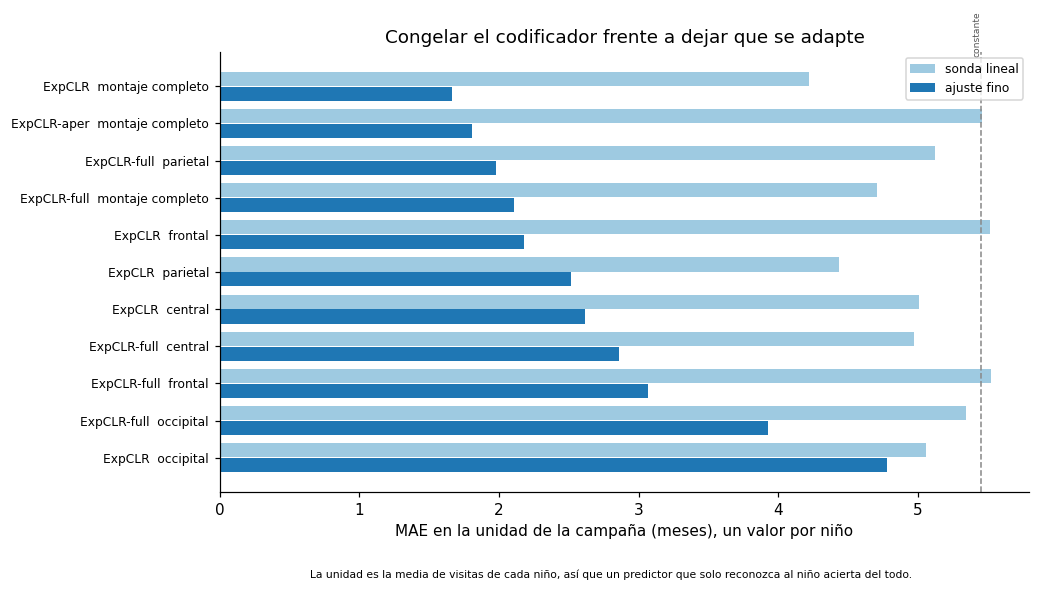


El ajuste fino baja el error en las 11 de 11 combinaciones, entre 0.28 y 3.66 meses.

Lectura: el preentrenamiento sirve como punto de partida aunque su espacio congelado
no supere al descriptor. Son dos afirmaciones distintas y el capitulo debe separarlas.


In [40]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
order = wide.sort_values("mae_ajuste fino")
positions = np.arange(len(order))
ax.barh(positions - 0.2, order["mae_sonda lineal"], height=0.38, label="sonda lineal",
        color="#9ecae1")
ax.barh(positions + 0.2, order["mae_ajuste fino"], height=0.38, label="ajuste fino",
        color="#1f77b4")
ax.axvline(np.mean(np.abs(reference_constant - reference_constant.mean())), ls="--", lw=1,
           color="#888888")
ax.text(np.mean(np.abs(reference_constant - reference_constant.mean())), -0.8,
        "constante", rotation=90, fontsize=6, va="bottom", ha="right", color="#555555")
ax.set_yticks(positions, [f"{m}  {ZONE_LABEL[z]}" for m, z in zip(order.metodo, order.zona)],
              fontsize=8)
ax.set_xlabel("MAE en la unidad de la campaña (meses), un valor por niño")
ax.set_title("Congelar el codificador frente a dejar que se adapte")
ax.legend(fontsize=8)
ax.invert_yaxis()
fig.text(0.5, -0.04,
         "La unidad es la media de visitas de cada niño, así que "
         "un predictor que solo reconozca al niño acierta del todo.", ha="center", fontsize=7)
fig.savefig(os.path.join(OUT, "ajuste_fino.png"))
plt.show()

gain = (wide["mae_sonda lineal"] - wide["mae_ajuste fino"])
print(f"\nEl ajuste fino baja el error en las {int((gain > 0).sum())} de {len(gain)} "
      f"combinaciones, entre {gain.min():.2f} y {gain.max():.2f} meses.")
print("\nLectura: el preentrenamiento sirve como punto de partida aunque su espacio congelado")
print("no supere al descriptor. Son dos afirmaciones distintas y el capitulo debe separarlas.")

## 15. Ablación de capa y robustez

En los ciento diez codificadores la pérdida actuó sobre la cabeza de proyección, pero el
repositorio lee unas veces esa capa y otras el embedding, y como ambas tienen ciento
veintiocho dimensiones nada delata la sustitución. Esta sección mide la diferencia entre las
dos con los mismos pesos, los mismos pliegues y la misma sonda.

A continuación se comprueban tres decisiones tomadas por el camino, con el fin de descartar
que el resultado dependa de ellas.

In [41]:
embedding_result = cached_combination("ExpCLR", "all", "embedding")
rows = []
for name, frame in [("proyección", reference["sessions"]),
                    ("embedding", embedding_result["sessions"])]:
    low, high = bootstrap_ci(frame, "mae")
    rows.append({"capa": name, **session_metrics(frame),
                 "mae_ic_bajo": low, "mae_ic_alto": high})
LAYERS = pd.DataFrame(rows)
LAYERS.to_csv(os.path.join(OUT, "ablacion_capa.csv"), index=False)
print(LAYERS.round(3).to_string(index=False))

diff = paired_bootstrap_difference(reference["sessions"], embedding_result["sessions"], "mae")
print(f"\nDiferencia pareada (proyección menos embedding): {diff['diff']:.3f} meses, "
      f"IC95 [{diff['ci_low']:.3f}, {diff['ci_high']:.3f}]")

      capa   mae    r2   rho  n_sessions  mae_ic_bajo  mae_ic_alto
proyección 7.797 0.296 0.401         274        6.969        8.593
 embedding 7.802 0.301 0.436         274        6.964        8.564



Diferencia pareada (proyección menos embedding): -0.005 meses, IC95 [-0.275, 0.253]


In [42]:
checks = [{"variante": "todas las sesiones", "n": len(best_sessions),
           "mae": session_metrics(best_sessions)["mae"]}]

counts = meta_best.groupby(["subject", "age", "block"]).size().rename("ventanas")
enriched = best_sessions.merge(counts.reset_index(), on=["subject", "age", "block"], how="left")
for minimum in (3, 5):
    kept = enriched[enriched.ventanas >= minimum]
    checks.append({"variante": f"sesiones con {minimum} ventanas o más", "n": len(kept),
                   "mae": session_metrics(kept)["mae"]})
no_unknown = best_sessions[best_sessions.block != -1]
checks.append({"variante": "sin el bloque sin identificar", "n": len(no_unknown),
               "mae": session_metrics(no_unknown)["mae"]})

ROBUSTNESS = pd.DataFrame(checks).assign(metodo=BEST[0], zona=BEST[1])
ROBUSTNESS.to_csv(os.path.join(OUT, "robustez.csv"), index=False)
print(f"Sobre {BEST[0]} en {ZONE_LABEL[BEST[1]]}, la combinación de referencia\n")
print(ROBUSTNESS.round(3).to_string(index=False))

Sobre ExpCLR en montaje completo, la combinación de referencia

                     variante   n   mae metodo zona
           todas las sesiones 274 7.797 ExpCLR  all
sesiones con 3 ventanas o más 227 7.766 ExpCLR  all
sesiones con 5 ventanas o más 185 7.711 ExpCLR  all
sin el bloque sin identificar 230 7.244 ExpCLR  all


## 16. Qué queda establecido, y qué no

### Lo que queda establecido

Cada afirmación remite a la tabla que la sostiene, y ninguna va más lejos que ella.

La representación no llega a distinguirse de no usar el EEG. La mejor combinación obtiene 7,80
meses de error y la mejor constante, que consiste en predecir la mediana para todos los casos,
obtiene 8,45, sin que el contraste pareado por sujeto excluya el cero
(`contraste_constante.csv`). Las comparaciones que el cuaderno hace después se establecen por
tanto entre espacios que, tomados como grupo, no han superado esa frontera.

El descriptor experto sin codificador gana con holgura, con 3,12 meses de error por 7,80 de la
mejor representación y una diferencia pareada de 4,67 meses e intervalo entre 3,83 y 5,47
sobre 274 sesiones (`contraste_primario.json`, `escalera.csv`). El paso contrastivo resta
entonces información respecto del descriptor que lo guía, y es el resultado mejor sostenido de
todo el cuaderno.

Ninguna de las once combinaciones agrupa por edad, ya que la silueta resulta negativa en todas
combinaciones y su rango completo mide 0,006 sobre una escala que va de -1 a 1
(`rejilla_silueta_edad.csv`).

La concentración de la visita de 36 meses depende de cómo se agregue el material. Antes de
proyectar los centroides a la esfera unidad, la señal cruda encabezaba la tabla, y el
diagnóstico recogido en `artefacto_centroide.csv` muestra que en ese espacio la norma del
centroide es casi una función del número de ventanas promediadas; dado que las sesiones de 36
meses son más largas, esa dependencia bastaba para producir la apariencia de concentración, y
una vez corregida el orden se invierte (`concentracion_36m.csv`).

El cociente no está en el latente, con R2 negativo en las once combinaciones y ningún contraste
que sobreviva la corrección múltiple, sobre una correlación detectable declarada índice por
índice (`cociente_sonda.csv`, `cognicion_finalistas.csv`). El resultado replica la limitación
que el trabajo previo declaró sobre estos mismos datos.

### Lo que no queda establecido

Los apartados siguientes recogen los límites de lo que estas cifras pueden sostener.

Queda sin comprobar que el latente respete la geometría del descriptor, que es la propiedad
que define a ExpCLR y cuya verificación exige comparar las distancias medidas en el descriptor
con las distancias en la representación. Sin esa medida, el cuaderno se pronuncia sobre la
utilidad del espacio y sobre su forma, pero no sobre su fidelidad al descriptor que lo guio.

Para las figuras se emplea un solo codificador, el del primer pliegue, que vio entrenando a
cuarenta de los cuarenta y cinco niños. Ese es el precio de disponer de un espacio coherente
que dibujar, y por eso lo cuantitativo se mide dentro de cada pliegue y no sobre el dibujo.

Los índices calculados sobre k-medias describen una partición sin llegar a demostrar que exista
estructura, razón por la cual se reportan siempre con sus controles al lado y nunca se emplean
para elegir entre combinaciones.

El trabajo emplea una sola semilla de partición y una sola de preentrenamiento, así que los
intervalos recogen el muestreo de la cohorte con los pliegues fijos y dejan fuera la
variabilidad que introduciría otra partición.

El cociente se mide sobre 39 niños, muestra con la que un resultado nulo resulta compatible con
un efecto real que estos datos no alcanzan a detectar.

La sonda lineal y el ajuste fino responden a preguntas distintas y se miden de forma distinta.
Todo lo que este cuaderno calcula se refiere a la representación congelada y se agrega por
sesiones, mientras las cifras de ajuste fino proceden de la campaña y llegan en su propia
unidad, un valor por niño obtenido como media de sus visitas, donde reconocer al niño basta
para acertar. Las dos lecturas conviven en la sección 14 y no deben mezclarse en una misma
tabla del capítulo.

In [43]:
print(f"Ficheros escritos en {OUT}\n")
for name in sorted(os.listdir(OUT)):
    path = os.path.join(OUT, name)
    if os.path.isfile(path):
        print(f"  {name:38s} {os.path.getsize(path) / 1024:8.1f} KB")
print(f"\n  cache/  {len(os.listdir(CACHE))} ficheros intermedios")
if ILL_CONDITIONED:
    print(f"\n[aviso] {len(ILL_CONDITIONED)} ajustes de la sonda encontraron una "
          "matriz mal condicionada: las 128 dimensiones del latente son fuertemente\n"
          "colineales, coherente con la dimensión efectiva de la sección 2. La ridge\n"
          "lo absorbe con su regularización, y el dato queda registrado aquí.")

Ficheros escritos en results/latent_expclr

  ablacion_capa.csv                           0.3 KB
  ajuste_fino.csv                             2.0 KB
  ajuste_fino.png                            71.1 KB
  ajuste_fino_referencias.csv                 0.1 KB
  artefacto_centroide.csv                     0.2 KB
  bandas_cociente.csv                         0.3 KB
  clusteres_metadatos.csv                     0.5 KB
  cobertura_por_cociente.csv                  0.2 KB
  cociente_sonda.csv                          0.9 KB
  cognicion_finalistas.csv                    3.2 KB
  composicion_clusteres.csv                   1.3 KB
  composicion_clusteres.png                  69.9 KB
  compresión.csv                              0.7 KB
  compresión.png                            112.5 KB
  concentracion_36m.csv                       2.6 KB
  concentracion_36m.png                      75.4 KB
  contraste_constante.csv                     0.1 KB
  contraste_primario.json                     0.1 KB
  